# 제조 생산데이터 기반 전력 사용량 예측 및 최대피크 위험조건 분석

## 실행 안내

이 노트북은 전처리, 피처 비교, 월별 시계열 평가, 고전력 가중치 학습, 다음 한 시간 예측, 오류 분석, 가상 부하 이동 분석, 사전 경고 가능 시간 분석을 순서대로 수행한다. **처음부터 전체 셀을 순서대로 실행한다.** 이미 실행한 출력은 정리된 코드로 다시 계산한 결과이다.

- 입력: `okm_augumented_2021.csv`. 첫 코드 셀의 `DATA_PATH`를 수정하거나 환경변수 `KAI_DATA_PATH`로 지정한다.
- 출력: `output/` 아래의 모델·피크·한 시간 예측·가상 시뮬레이션·오류 분석·최종 요약 폴더. `KAI_OUTPUT_ROOT`로 출력 폴더를 변경할 수 있다.
- 패키지: NumPy, pandas, Matplotlib, scikit-learn, SciPy, joblib, threadpoolctl. IPython은 표 표시용이며 일반 Python에서는 텍스트 표시로 대체한다.
- 모델 설정, 전처리 방식, 평가 월, 가중치와 시나리오는 기존 실행본과 동일하게 유지하였다. 실행 패키지 버전은 `execution_environment.json`에 기록한다.
- 재현 확인 환경은 Python 3.12, pandas 2.2.3, scikit-learn 1.8.0, SciPy 1.17.0이다.

## 평가와 해석 범위

4~8월은 월별 확장 학습의 평가 및 설정 비교에 사용한 구간이다. 여러 후보와 운영 규칙을 같은 기간에서 탐색하였으므로 새로운 독립 검증으로 해석하지 않는다. 9월은 이전에 확인한 평가 결과를 재현하는 구간이며 독립 미열람 테스트라고 표현하지 않는다.

실제 고전력 정의는 월별 학습 전력의 P95이다. 예측 경보 기준만 그 기준의 85~100%로 변경한다. 정시 한 시간 창, 15분 표본, 연속 고전력 구간의 시작 사례는 서로 다른 집계 단위이다.

생산량은 시간 단위로 관측되며 15분 단위 생산량 이동은 입증되지 않았다. 부하 배정과 조건부 재생은 가정을 둔 전력 대리량 시뮬레이션이다. 실제 생산 조정, 실측 피크 저감, 전기요금 절감액을 검증한 것으로 해석하지 않는다.

## 피처 구성

| 구분 | 구성 | 개수 |
|---|---|---:|
| A | 전력 지연값 6개, 이동 평균·최대·표준편차 9개, 변화량 2개, 직전 전력 0 여부 1개, 완료 생산량 관련 4개 | 22 |
| B | A + 시간·15분 위치·요일·주말 여부 | 26 |
| C | B + 요일×시간 조합, 시간 sin/cos, 월 sin/cos | 31 |

`lag_1/2/4/8/96/672`는 15분 표본 기준 각각 15분·30분·1시간·2시간·1일·1주일 전 전력이다. `roll_*_4/24/96`은 최근 완료된 1시간·6시간·1일 전력의 통계이다. `delta_1h`는 직전 완료 전력과 그보다 한 시간 앞선 완료 전력의 차이이다. 생산량 피처는 완료 생산량, 직전 완료 시간 대비 변화, 양수 여부, `log(1+생산량)`이다.


## 1. 데이터와 실행 설정

### 01. 실행 환경과 공통 설정

입력 경로와 출력 경로를 지정하고, 패키지와 공통 설정을 한 번만 불러온다. 원본 파일 이름과 해시, 실행 패키지 버전을 기록한다.

In [1]:
import os

os.environ.setdefault("OMP_NUM_THREADS", "2")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")

from pathlib import Path
import json
import platform
import hashlib

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
from scipy.optimize import linprog
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from threadpoolctl import threadpool_limits

try:
    from IPython.display import display
except ImportError:

    def display(value):
        print(value.to_string() if hasattr(value, "to_string") else value)


# 입력 파일을 다른 위치에 두었다면 이 경로를 수정한다.
DATA_PATH = Path(os.environ.get("KAI_DATA_PATH", "okm_augumented_2021.csv"))
OUTPUT_ROOT = Path(os.environ.get("KAI_OUTPUT_ROOT", "output"))
YEAR = 2021
VALIDATION_MONTHS = tuple(range(4, 9))
POWER_COLUMNS = ["15분", "30분", "45분", "60분"]
LAGS = [1, 2, 4, 8, 96, 672]
ROLL_WINDOWS = [4, 24, 96]
HORIZONS = [15, 30, 45, 60]
HOUR_WEIGHTS = [1, 5]
HOUR_MODELS = ["Persistence", "WeeklyNaive", "HGB_w1", "HGB_w5"]
PEAK_WEIGHTS = [1, 2, 3, 5]
ALARM_RATIOS = [0.85, 0.90, 0.95, 1.00]
LEAD_MINUTES = [45, 30, 15, 0]
SCENARIO = "20pct_30min"
EPS = 1e-6

MODEL_OUT = OUTPUT_ROOT / "kai_models"
PEAK_OUT = OUTPUT_ROOT / "kai_peak"
HOUR_OUT = OUTPUT_ROOT / "kai_hour"
OPT_OUT = OUTPUT_ROOT / "kai_optimization"
FOLLOW_OUT = OUTPUT_ROOT / "kai_followup"
CLOSEOUT_OUT = OUTPUT_ROOT / "kai_closeout"
for folder in [MODEL_OUT, PEAK_OUT, HOUR_OUT, OPT_OUT, FOLLOW_OUT, CLOSEOUT_OUT]:
    folder.mkdir(parents=True, exist_ok=True)

plt.rcParams.update(
    {
        "font.size": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)


def save_table(table, path, *, index=False):
    """결과표를 Excel에서 읽을 수 있는 UTF-8 BOM CSV로 저장한다."""
    table.to_csv(path, index=index, encoding="utf-8-sig")


def save_figure(figure, path, *, dpi=150, **kwargs):
    """그래프를 저장하고 노트북에 표시한 후 메모리를 해제한다."""
    figure.savefig(path, dpi=dpi, **kwargs)
    plt.show()
    plt.close(figure)


if not DATA_PATH.exists():
    candidates = []
    for folder in [Path.cwd(), Path("data"), Path("/content"), Path("upload")]:
        candidates.extend(folder.glob("okm_augumented_2021*.csv"))
    candidates.extend(Path("attachments").rglob("okm_augumented_2021*.csv"))
    candidates = list(dict.fromkeys(path.resolve() for path in candidates))
    if len(candidates) != 1:
        raise FileNotFoundError(
            "DATA_PATH에 원본 CSV의 정확한 경로를 지정하세요. "
            f"자동 검색 후보 수: {len(candidates)}"
        )
    DATA_PATH = candidates[0]

raw = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
required_columns = {
    "날짜",
    "시간",
    "풍속",
    "강수량",
    "공장인원",
    "생산량",
    *POWER_COLUMNS,
}
missing_columns = required_columns.difference(raw.columns)
if missing_columns:
    raise ValueError(f"필수 열이 없습니다: {sorted(missing_columns)}")

print(f"입력 파일: {DATA_PATH.name} / 크기: {raw.shape}")
print(f"결과 저장 위치: {OUTPUT_ROOT.resolve()}")
environment = {
    "Python": platform.python_version(),
    "NumPy": np.__version__,
    "pandas": pd.__version__,
    "scikit-learn": sklearn.__version__,
    "SciPy": scipy.__version__,
    "joblib": joblib.__version__,
    "source_file": DATA_PATH.name,
    "source_sha256": hashlib.sha256(DATA_PATH.read_bytes()).hexdigest(),
    "validation_months": list(VALIDATION_MONTHS),
}
(OUTPUT_ROOT / "execution_environment.json").write_text(
    json.dumps(environment, ensure_ascii=False, indent=2), encoding="utf-8"
)


입력 파일: okm_augumented_2021.csv / 크기: (6168, 18)
결과 저장 위치: /content/output


330

### 02. 데이터 전처리와 15분 시계열 구성

7월 13일·15일은 원본 행 순서대로 시간을 0~23시로 복원한다. 풍속은 시간 보간, 강수량과 공장인원 결측은 0으로 처리한다. 네 전력 열을 15분 시계열로 변환하고 중복·누락을 점검한다.

In [ ]:
# 원본 행 순서를 유지한 상태에서 날짜 이상치의 시간을 복원한다.
# 결측치 처리 후 15분 시계열의 연속성을 확인한다.
hourly = raw.copy().reset_index(drop=True)
hourly["hour_restored"] = hourly["날짜"].isin([20210713, 20210715])
for date in [20210713, 20210715]:
    idx = hourly.index[hourly["날짜"].eq(date)]
    assert len(idx) == 24, f"{date}: expected 24 original rows"
    hourly.loc[idx, "시간"] = np.arange(24)
hourly["timestamp"] = pd.to_datetime(
    hourly["날짜"].astype(str), format="%Y%m%d"
) + pd.to_timedelta(hourly["시간"], unit="h")
hourly = hourly.sort_values("timestamp").reset_index(drop=True)
hourly["풍속"] = (
    hourly.set_index("timestamp")["풍속"].interpolate(method="time").to_numpy()
)
hourly["강수량"] = hourly["강수량"].fillna(0)
hourly["공장인원"] = hourly["공장인원"].fillna(0)
assert not hourly["timestamp"].duplicated().any()
assert hourly["timestamp"].diff().dropna().eq(pd.Timedelta(hours=1)).all()
assert not hourly[raw.columns].isna().any().any()
long = hourly.melt(
    id_vars=["timestamp", "hour_restored"],
    value_vars=POWER_COLUMNS,
    var_name="quarter",
    value_name="power",
)
long["timestamp"] += pd.to_timedelta(
    long["quarter"].map({"15분": 0, "30분": 15, "45분": 30, "60분": 45}), unit="m"
)
long = long.sort_values("timestamp").set_index("timestamp")
assert not long.index.duplicated().any()
assert long.index.to_series().diff().dropna().eq(pd.Timedelta(minutes=15)).all()
print(
    "Hourly rows:",
    len(hourly),
    "15-minute rows:",
    len(long),
    "restored quarters:",
    long["hour_restored"].sum(),
)


Hourly rows: 6168 15-minute rows: 24672 restored quarters: 192


### 03. 과거 정보 기반 피처 생성

시각 t는 [t, t+15분) 구간의 시작이다. 지연값과 이동통계는 t 이전 완료 구간만 사용한다. 생산량은 해당 시간이 끝난 뒤 사용한다. A는 22개, B는 달력 4개를 더한 26개, C는 조합·주기 5개를 더한 31개이다. 공장인원과 원본 전력 평균은 입력에서 제외한다.

In [3]:
# 현재 예측 대상 전력을 지연시킨 값으로만 관측 피처를 만든다.
# 시간 단위 생산량은 해당 시간이 완료된 시점부터 사용할 수 있다.
feature_data = pd.DataFrame(index=long.index)
feature_data["target"] = long["power"].astype(float)
for lag in LAGS:
    feature_data[f"lag_{lag}"] = feature_data["target"].shift(lag)
# 현재 정답을 제외한 완료 전력으로 이동통계를 계산한다.
past = feature_data["target"].shift(1)
for win in ROLL_WINDOWS:
    feature_data[f"roll_mean_{win}"] = past.rolling(win, min_periods=win).mean()
    feature_data[f"roll_max_{win}"] = past.rolling(win, min_periods=win).max()
    feature_data[f"roll_std_{win}"] = past.rolling(win, min_periods=win).std(ddof=0)
feature_data["delta_15m"] = feature_data["lag_1"] - feature_data["lag_2"]
feature_data["delta_1h"] = feature_data["lag_1"] - feature_data["target"].shift(5)
feature_data["previous_power_zero"] = feature_data["lag_1"].eq(0).astype(int)
release_times = pd.DatetimeIndex(hourly["timestamp"] + pd.Timedelta(hours=1))
released_production = pd.Series(
    hourly["생산량"].to_numpy(dtype=float), index=release_times
)
feature_data["production_known"] = released_production.reindex(
    feature_data.index, method="ffill"
)
feature_data["production_change"] = released_production.diff().reindex(
    feature_data.index, method="ffill"
)
feature_data["production_positive"] = feature_data["production_known"].gt(0).astype(int)
feature_data["production_log"] = np.log1p(feature_data["production_known"])
feature_data["hour"] = feature_data.index.hour
feature_data["quarter_id"] = feature_data.index.minute // 15
feature_data["weekday"] = feature_data.index.dayofweek
feature_data["weekend"] = feature_data["weekday"].ge(5).astype(int)
feature_data["weekday_hour"] = feature_data["weekday"] * 24 + feature_data["hour"]
phase = (feature_data["hour"] + feature_data["quarter_id"] / 4) / 24
feature_data["hour_sin"] = np.sin(2 * np.pi * phase)
feature_data["hour_cos"] = np.cos(2 * np.pi * phase)
feature_data["month_sin"] = np.sin(2 * np.pi * (feature_data.index.month - 1) / 12)
feature_data["month_cos"] = np.cos(2 * np.pi * (feature_data.index.month - 1) / 12)
feature_data["hour_restored"] = long["hour_restored"].astype(bool)
BASE = [c for c in feature_data.columns if c.startswith(("lag_", "roll_"))]
BASE += [
    "delta_15m",
    "delta_1h",
    "previous_power_zero",
    "production_known",
    "production_change",
    "production_positive",
    "production_log",
]
CALENDAR = ["hour", "quarter_id", "weekday", "weekend"]
DETAIL = ["weekday_hour", "hour_sin", "hour_cos", "month_sin", "month_cos"]
FEATURES = {"A": BASE, "B": BASE + CALENDAR, "C": BASE + CALENDAR + DETAIL}
feature_data = feature_data.dropna(subset=FEATURES["C"]).copy()
assert "target" not in FEATURES["C"]
assert "hour_restored" not in FEATURES["C"]
check_t = pd.Timestamp("2021-02-01 08:15")
assert (
    feature_data.loc[check_t, "production_known"]
    == hourly.set_index("timestamp").loc["2021-02-01 07:00", "생산량"]
)
assert feature_data.loc[check_t, "lag_1"] == long.loc["2021-02-01 08:00", "power"]
print(
    "Usable samples:",
    len(feature_data),
    "feature counts:",
    {k: len(v) for k, v in FEATURES.items()},
)
display(
    feature_data.loc[
        "2021-02-01 07:45":"2021-02-01 08:30",
        ["target", "lag_1", "production_known", "hour", "weekday"],
    ]
)


Usable samples: 24000 feature counts: {'A': 22, 'B': 26, 'C': 31}


,target,lag_1,production_known,hour,weekday
timestamp,,,,,
2021-02-01 07:45:00,139.0,139.0,0.0,7,0
2021-02-01 08:00:00,165.0,139.0,0.0,8,0
2021-02-01 08:15:00,178.0,165.0,0.0,8,0
2021-02-01 08:30:00,179.0,178.0,0.0,8,0


## 2. 기본 모델과 시계열 검증

### 04. 비교 모델과 평가 지표

Persistence는 직전 완료 전력, WeeklyNaive는 일주일 전 같은 구간 전력을 예측값으로 사용한다. Ridge와 HistGradientBoostingRegressor(HGB)는 A·B·C를 비교한다. MAE·RMSE는 전체 오차, peak_MAE는 고전력 사례의 오차이며, peak_underprediction은 고전력 사례에서 max(실제−예측, 0)의 평균이다.

In [4]:
SPECS = ["Persistence", "WeeklyNaive"] + [
    f"{family}_{level}" for family in ["Ridge", "HGB"] for level in ["A", "B", "C"]
]
CATEGORY_COLS = ["hour", "quarter_id", "weekday", "weekday_hour"]


def make_model(spec):
    """모델 종류와 피처 세트에 맞는 회귀 모델을 생성한다."""
    family, level = spec.split("_")
    cols = FEATURES[level]
    categories = [c for c in CATEGORY_COLS if c in cols]
    numeric = [c for c in cols if c not in categories]
    if family == "Ridge":
        transforms = [("numeric", StandardScaler(), numeric)]
        if categories:
            transforms.append(
                (
                    "calendar",
                    OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                    categories,
                )
            )
        return Pipeline(
            [("features", ColumnTransformer(transforms)), ("model", Ridge(alpha=10.0))]
        )
    return HistGradientBoostingRegressor(
        max_iter=160,
        learning_rate=0.06,
        max_leaf_nodes=15,
        min_samples_leaf=40,
        l2_regularization=1.0,
        categorical_features=categories if categories else None,
        early_stopping=False,
        random_state=42,
    )


def fit_predict(spec, train, evaluation):
    """학습 데이터로 모델을 학습하고 평가 데이터의 비음수 예측값을 반환한다."""
    if spec == "Persistence":
        return (evaluation["lag_1"].to_numpy(), None)
    if spec == "WeeklyNaive":
        return (evaluation["lag_672"].to_numpy(), None)
    cols = FEATURES[spec.split("_")[1]]
    estimator = make_model(spec)
    with threadpool_limits(limits=2):
        estimator.fit(train[cols], train["target"])
        pred = estimator.predict(evaluation[cols])
    return (np.maximum(pred, 0), estimator)


def metrics(y, pred, peak_threshold, weekday=None):
    """전체 오차, 고전력 오차, 경보 지표를 동일한 기준으로 계산한다."""
    y, pred = (np.asarray(y), np.asarray(pred))
    high = y >= peak_threshold
    alarm = pred >= peak_threshold
    tp = int((high & alarm).sum())
    result = dict(
        n=len(y),
        MAE=mean_absolute_error(y, pred),
        RMSE=np.sqrt(mean_squared_error(y, pred)),
        peak_threshold=float(peak_threshold),
        peak_n=int(high.sum()),
        peak_MAE=float(np.mean(np.abs(y[high] - pred[high]))) if high.any() else np.nan,
        peak_underprediction=(
            float(np.mean(np.maximum(y[high] - pred[high], 0)))
            if high.any()
            else np.nan
        ),
        peak_recall=tp / high.sum() if high.any() else np.nan,
        alarm_precision=tp / alarm.sum() if alarm.any() else np.nan,
        false_alarm_n=int((~high & alarm).sum()),
    )
    if weekday is not None:
        d = pd.DataFrame({"error": np.abs(y - pred), "weekday": np.asarray(weekday)})
        result["weekday_macro_MAE"] = d.groupby("weekday")["error"].mean().mean()
    return result


### 05. 월별 확장 학습으로 모델·피처 비교

4월은 1~3월로, 5월은 1~4월로 학습하는 확장 학습을 8월까지 수행한다. 기준은 매월 학습 전력의 95백분위수(P95)이며 전체 평가 데이터를 사용해 계산하지 않는다. 요일별 MAE의 평균도 함께 계산한다.

In [5]:
# 각 평가 월보다 앞선 데이터만 학습에 사용한다.
validation_rows, validation_predictions = ([], [])
for month in VALIDATION_MONTHS:
    start = pd.Timestamp(YEAR, month, 1)
    end = start + pd.offsets.MonthBegin(1)
    train = feature_data.loc[feature_data.index < start]
    evaluate = feature_data.loc[
        (feature_data.index >= start) & (feature_data.index < end)
    ]
    threshold = train["target"].quantile(0.95)
    for spec in SPECS:
        pred, _ = fit_predict(spec, train, evaluate)
        row = metrics(evaluate["target"], pred, threshold, evaluate["weekday"])
        row.update(model=spec, fold_month=month, train_n=len(train))
        validation_rows.append(row)
        pr = pd.DataFrame(
            {
                "timestamp": evaluate.index,
                "actual": evaluate["target"].to_numpy(),
                "prediction": pred,
                "model": spec,
                "fold_month": month,
                "threshold": threshold,
            }
        )
        validation_predictions.append(pr)
    print(
        "Finished validation month",
        month,
        "train",
        len(train),
        "evaluate",
        len(evaluate),
    )
validation = pd.DataFrame(validation_rows)
oof = pd.concat(validation_predictions, ignore_index=True)
summary = (
    validation.groupby("model")[
        [
            "MAE",
            "RMSE",
            "weekday_macro_MAE",
            "peak_MAE",
            "peak_underprediction",
            "peak_recall",
        ]
    ]
    .mean()
    .sort_values("MAE")
)
save_table(validation, MODEL_OUT / "monthly_validation.csv", index=False)
display(summary.round(4))


Finished validation month 4 train 7968 evaluate 2880
Finished validation month 5 train 10848 evaluate 2976
Finished validation month 6 train 13824 evaluate 2880
Finished validation month 7 train 16704 evaluate 2976
Finished validation month 8 train 19680 evaluate 2976


,MAE,RMSE,weekday_macro_MAE,peak_MAE,peak_underprediction,peak_recall
model,,,,,,
HGB_B,5.3094,7.9634,5.3161,9.5173,8.8917,0.4629
HGB_C,5.5764,8.3454,5.5800,10.0430,9.5166,0.4474
HGB_A,5.9880,9.1064,5.9829,10.9141,10.2075,0.4183
Ridge_C,7.8964,11.1428,7.9034,11.5592,10.0144,0.4976
Persistence,8.1868,14.0462,8.1872,11.7327,10.0912,0.5618
Ridge_B,8.4058,11.7550,8.4163,11.6282,10.1210,0.5030
Ridge_A,8.5153,12.7129,8.5313,12.8637,11.4422,0.4541
WeeklyNaive,22.3679,38.7929,22.6234,40.8046,39.5216,0.2934


### 06. 최근 3개월 학습과 확장 학습 비교

4~8월의 월별 평균 MAE로 선택한 모델에 대해 최근 3개월 학습을 비교한다. 학습 창 비교에서 고전력 판단 기준은 확장 학습의 기준으로 동일하게 유지한다.

In [6]:
candidate_summary = summary.loc[
    [s for s in summary.index if s not in ["Persistence", "WeeklyNaive"]]
]
chosen_spec = candidate_summary.index[0]
sliding_rows = []
for month in VALIDATION_MONTHS:
    start = pd.Timestamp(YEAR, month, 1)
    end = start + pd.offsets.MonthBegin(1)
    training_start = start - pd.DateOffset(months=3)
    train = feature_data.loc[
        (feature_data.index >= training_start) & (feature_data.index < start)
    ]
    evaluate = feature_data.loc[
        (feature_data.index >= start) & (feature_data.index < end)
    ]
    pred, _ = fit_predict(chosen_spec, train, evaluate)
    threshold = feature_data.loc[feature_data.index < start, "target"].quantile(0.95)
    row = metrics(evaluate["target"], pred, threshold, evaluate["weekday"])
    row.update(
        model=chosen_spec, fold_month=month, train_n=len(train), window="last_3_months"
    )
    sliding_rows.append(row)
sliding = pd.DataFrame(sliding_rows)
expanding_selected = validation.loc[validation["model"].eq(chosen_spec)]
window_scores = pd.DataFrame(
    {
        "expanding": expanding_selected[["MAE", "RMSE", "peak_MAE"]].mean(),
        "last_3_months": sliding[["MAE", "RMSE", "peak_MAE"]].mean(),
    }
).T
chosen_window = window_scores["MAE"].idxmin()
save_table(sliding, MODEL_OUT / "sliding_validation.csv", index=False)
print("Chosen using April-August MAE only:", chosen_spec, chosen_window)
display(window_scores.round(4))


Chosen using April-August MAE only: HGB_B expanding


,MAE,RMSE,peak_MAE
expanding,5.3094,7.9634,9.5173
last_3_months,5.3349,8.0034,9.6364


### 07. 9월의 기존 평가 결과 재현

4~8월에서 선택한 설정으로 기존 9월 평가를 재현하고 선택 모델을 저장한다. 9월 결과는 이전 분석에서 이미 확인하였으므로, 새로운 독립 미열람 테스트 성능으로 해석하지 않는다. 이후 피크 실험은 4~8월을 사용한다.

In [7]:
# 이미 확인한 9월 평가 결과를 재현하며 이 결과로 설정을 다시 선택하지 않는다.
split = pd.Timestamp("2021-09-01")
test = feature_data.loc[feature_data.index >= split].copy()
train = feature_data.loc[feature_data.index < split]
final_threshold = train["target"].quantile(0.95)
test_specs = list(
    dict.fromkeys(["Persistence", "WeeklyNaive", "Ridge_C", "HGB_C", chosen_spec])
)
final_rows, september_prediction_parts = ([], [])
for spec in test_specs:
    pred, fitted = fit_predict(spec, train, test)
    if spec == chosen_spec and chosen_window == "expanding":
        joblib.dump(fitted, MODEL_OUT / "selected_model.joblib")
    label = spec + "_expanding" if spec not in ["Persistence", "WeeklyNaive"] else spec
    row = metrics(test["target"], pred, final_threshold, test["weekday"])
    row.update(model=label)
    final_rows.append(row)
    september_prediction_parts.append(
        pd.DataFrame(
            {
                "timestamp": test.index,
                "actual": test["target"].to_numpy(),
                "prediction": pred,
                "model": label,
                "threshold": final_threshold,
            }
        )
    )
selected_label = chosen_spec + "_expanding"
if chosen_window == "last_3_months":
    recent = train.loc[train.index >= split - pd.DateOffset(months=3)]
    pred, fitted = fit_predict(chosen_spec, recent, test)
    joblib.dump(fitted, MODEL_OUT / "selected_model.joblib")
    selected_label = chosen_spec + "_last_3_months"
    row = metrics(test["target"], pred, final_threshold, test["weekday"])
    row.update(model=selected_label)
    final_rows.append(row)
    september_prediction_parts.append(
        pd.DataFrame(
            {
                "timestamp": test.index,
                "actual": test["target"].to_numpy(),
                "prediction": pred,
                "model": selected_label,
                "threshold": final_threshold,
            }
        )
    )
final = pd.DataFrame(final_rows).set_index("model")
test_predictions = pd.concat(september_prediction_parts, ignore_index=True)
save_table(final, MODEL_OUT / "final_september_metrics.csv", index=True)
save_table(test_predictions, MODEL_OUT / "final_september_predictions.csv", index=False)
print("Validation-selected final model:", selected_label)
metadata = {
    "model": selected_label,
    "features": FEATURES[chosen_spec.split("_")[1]],
    "peak_threshold": float(final_threshold),
    "forecast": "next 15-minute interval, observed history updates every 15 minutes",
    "production_availability": "previous fully completed hourly record",
    "selection": "April-August mean monthly MAE; September was previously inspected and is not an untouched test",
    "train_end_exclusive": str(split),
    "window": chosen_window,
}
(MODEL_OUT / "model_metadata.json").write_text(
    json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8"
)
display(final.round(4))


Validation-selected final model: HGB_B_expanding


,n,MAE,RMSE,peak_threshold,peak_n,peak_MAE,peak_underprediction,peak_recall,alarm_precision,false_alarm_n,weekday_macro_MAE
model,,,,,,,,,,,
Persistence,1344,8.7254,14.3495,180.0,87,10.6897,9.9195,0.4598,0.4598,47,8.7254
WeeklyNaive,1344,9.1793,13.0972,180.0,87,12.5862,11.9310,0.3908,0.3469,64,9.1793
Ridge_C_expanding,1344,7.1712,10.4092,180.0,87,9.6042,8.5616,0.4943,0.5890,30,7.1712
HGB_C_expanding,1344,4.7715,7.3900,180.0,87,8.1102,7.9337,0.5057,0.6377,25,4.7715
HGB_B_expanding,1344,4.9254,7.5754,180.0,87,7.9843,7.7638,0.5287,0.6765,22,4.9254


### 08. 생산 조건과 데이터 특성별 오류 분석

요일·시간·주말·복원 날짜·실제 전력 0 여부와 과거 동일 하루 패턴 여부에 따라 예측 오류를 분석한다. 하루 전체 실제값으로 만든 패턴 표시는 사후 진단용이며 예측 입력에 사용하지 않는다.

In [8]:
# 전체 실제 하루 패턴은 사후 진단용이며 모델의 입력 피처가 아니다.
daily_profiles = {
    date: tuple(group.sort_values("timestamp")[POWER_COLUMNS].to_numpy().ravel())
    for date, group in hourly.groupby("날짜")
}


def profile_seen_flags(index, training_end):
    """과거의 동일한 하루 전력 패턴 존재 여부를 사후 분석용으로 반환한다."""
    past_dates = hourly.loc[hourly["timestamp"] < training_end, "날짜"].unique()
    known = {daily_profiles[date] for date in past_dates}
    return np.array([daily_profiles[int(t.strftime("%Y%m%d"))] in known for t in index])


conditional = []
for month in VALIDATION_MONTHS:
    part = oof.loc[oof["model"].eq(chosen_spec) & oof["fold_month"].eq(month)].copy()
    idx = pd.DatetimeIndex(part["timestamp"])
    part["weekday"] = idx.dayofweek
    part["hour"] = idx.hour
    part["weekend"] = idx.dayofweek >= 5
    part["restored"] = feature_data.loc[idx, "hour_restored"].to_numpy()
    part["zero_actual"] = part["actual"].eq(0)
    part["seen_profile"] = profile_seen_flags(idx, pd.Timestamp(YEAR, month, 1))
    part["abs_error"] = (part["actual"] - part["prediction"]).abs()
    for condition in [
        "weekday",
        "hour",
        "weekend",
        "restored",
        "zero_actual",
        "seen_profile",
    ]:
        q = (
            part.groupby(condition)
            .agg(n=("abs_error", "size"), MAE=("abs_error", "mean"))
            .reset_index()
        )
        q = q.rename(columns={condition: "condition_value"})
        q["condition"] = condition
        q["fold_month"] = month
        conditional.append(q)
conditions = pd.concat(conditional, ignore_index=True)
save_table(conditions, MODEL_OUT / "conditional_validation_errors.csv", index=False)
display(
    conditions.loc[
        conditions["condition"].isin(["restored", "zero_actual", "seen_profile"])
    ]
)


,condition_value,n,MAE,condition,fold_month
33,0,2880,5.804380,restored,4
34,0,2880,5.804380,zero_actual,4
35,0,2880,5.804380,seen_profile,4
69,0,2976,4.581778,restored,5
70,0,2976,4.581778,zero_actual,5
71,0,1344,4.999818,seen_profile,5
72,1,1632,4.237509,seen_profile,5
106,0,2880,4.154931,restored,6
107,0,2880,4.154931,zero_actual,6
108,0,192,1.384776,seen_profile,6


### 09. 기본 모델의 결과 시각화

모델별 월별 오차, 9월 실제값과 예측값, 요일×시간의 오류 분포를 시각화한다. 저장한 그래프의 전력 단위는 원본 자료의 수치 단위를 따른다.

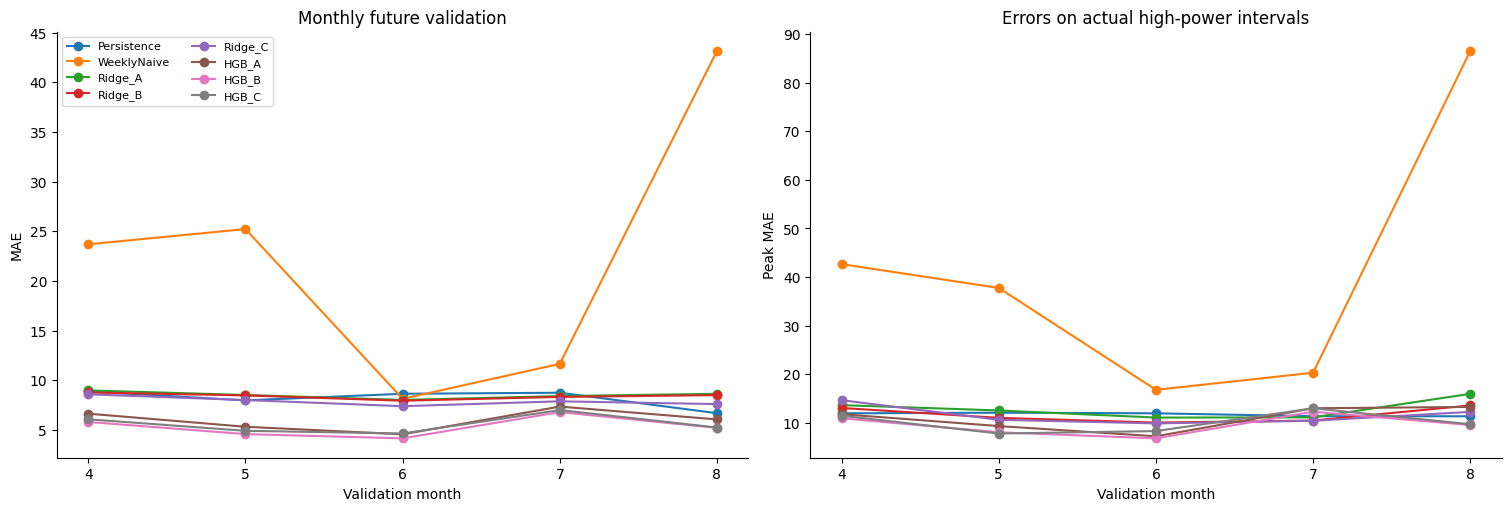

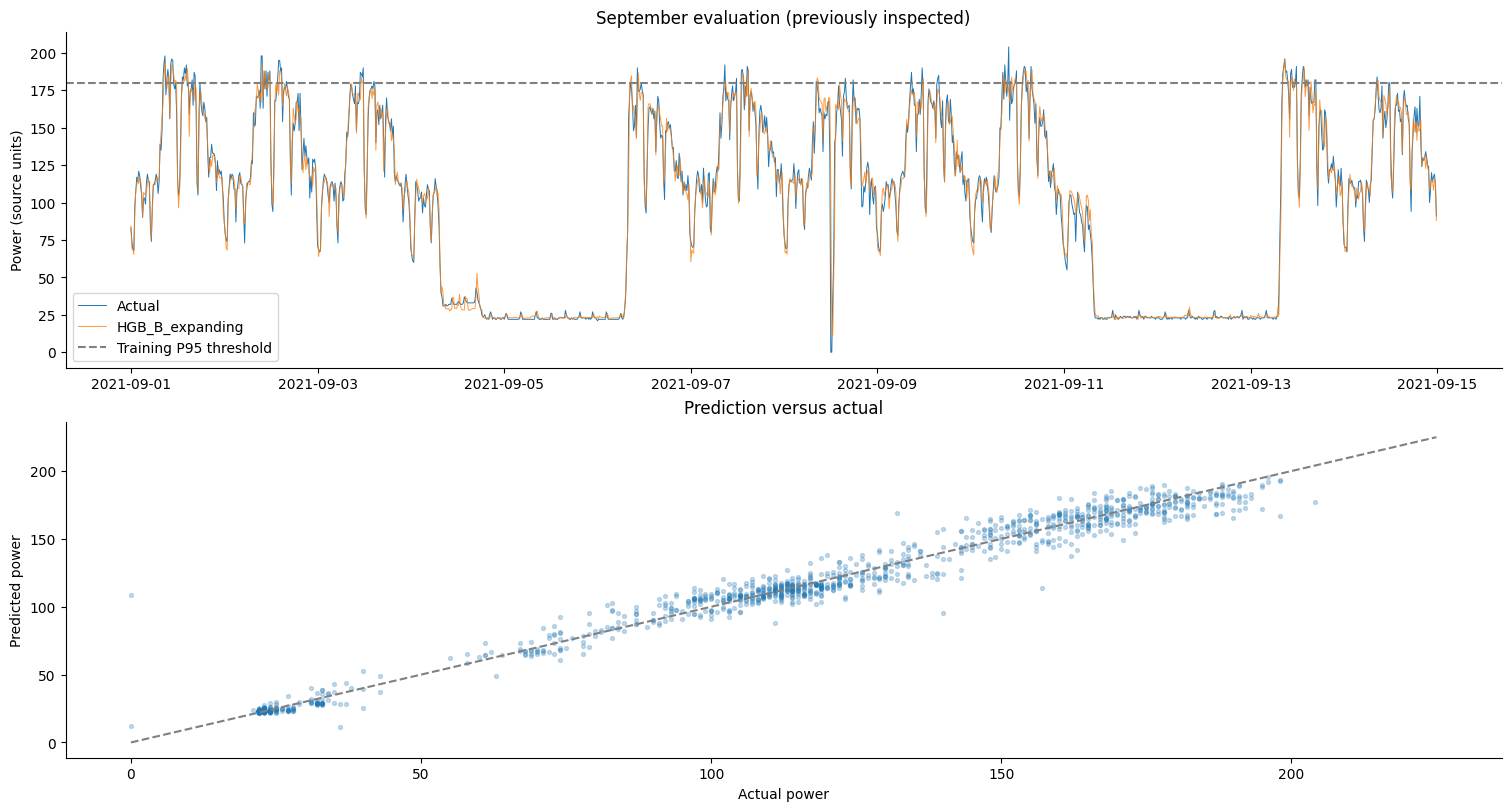

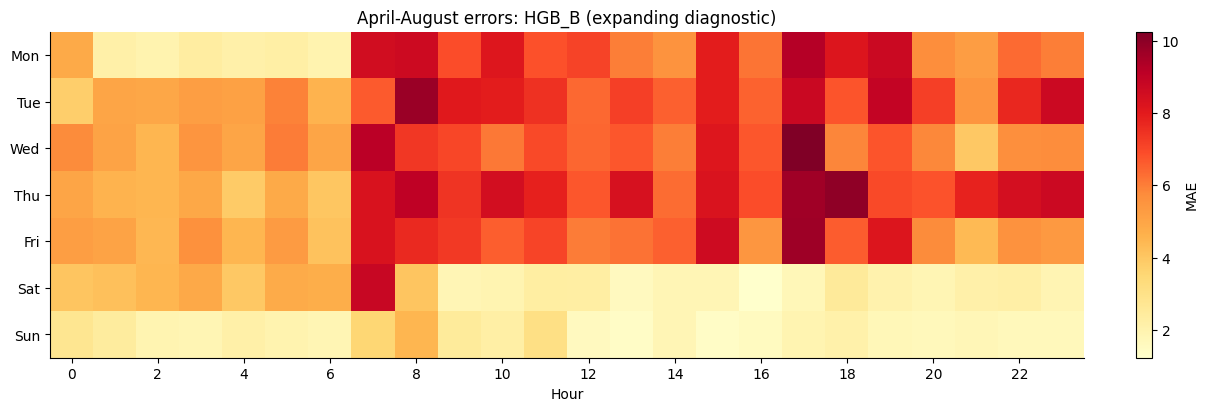

분석 완료: 9월은 이미 확인한 평가 구간이며 미열람 테스트가 아닙니다.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
for spec in SPECS:
    z = validation.loc[validation["model"].eq(spec)]
    axes[0].plot(z["fold_month"], z["MAE"], marker="o", label=spec)
    axes[1].plot(z["fold_month"], z["peak_MAE"], marker="o", label=spec)
axes[0].set(
    title="Monthly future validation",
    xlabel="Validation month",
    ylabel="MAE",
    xticks=VALIDATION_MONTHS,
)
axes[1].set(
    title="Errors on actual high-power intervals",
    xlabel="Validation month",
    ylabel="Peak MAE",
    xticks=VALIDATION_MONTHS,
)
axes[0].legend(fontsize=8, ncol=2)
save_figure(fig, MODEL_OUT / "01_monthly_validation.png", dpi=150)
selected_test = (
    test_predictions.loc[test_predictions["model"].eq(selected_label)]
    .copy()
    .set_index("timestamp")
)
fig, axes = plt.subplots(2, 1, figsize=(15, 8), constrained_layout=True)
axes[0].plot(selected_test.index, selected_test.actual, label="Actual", lw=0.7)
axes[0].plot(
    selected_test.index,
    selected_test.prediction,
    label=selected_label,
    lw=0.7,
    alpha=0.8,
)
axes[0].axhline(final_threshold, color="gray", ls="--", label="Training P95 threshold")
axes[0].set(
    title="September evaluation (previously inspected)", ylabel="Power (source units)"
)
axes[0].legend()
axes[1].scatter(selected_test.actual, selected_test.prediction, s=8, alpha=0.25)
axes[1].plot([0, 225], [0, 225], color="gray", ls="--")
axes[1].set(
    title="Prediction versus actual", xlabel="Actual power", ylabel="Predicted power"
)
save_figure(fig, MODEL_OUT / "02_september_forecast.png", dpi=150)
part = oof.loc[oof["model"].eq(chosen_spec)].copy()
idx = pd.DatetimeIndex(part.timestamp)
part["weekday"] = idx.dayofweek
part["hour"] = idx.hour
part["abs_error"] = (part.actual - part.prediction).abs()
heat = part.pivot_table(
    index="weekday", columns="hour", values="abs_error", aggfunc="mean"
).reindex(range(7))
fig, ax = plt.subplots(figsize=(12, 4), constrained_layout=True)
im = ax.imshow(heat, aspect="auto", cmap="YlOrRd")
fig.colorbar(im, ax=ax, label="MAE")
ax.set(
    title=f"April-August errors: {chosen_spec} (expanding diagnostic)",
    xlabel="Hour",
    yticks=range(7),
    yticklabels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],
    xticks=range(0, 24, 2),
)
save_figure(fig, MODEL_OUT / "03_weekday_hour_errors.png", dpi=150)
print("분석 완료: 9월은 이미 확인한 평가 구간이며 미열람 테스트가 아닙니다.")


## 3. 피크 가중치와 오류 조건

### 10. 피크 대응 모델의 학습 창 비교

선택된 HGB_B의 기존 확장·최근 3개월 결과를 재사용하여 피크 구간 성능과 오경보를 비교한다. 같은 모델을 불필요하게 다시 학습하지 않는다.

,fold_month,window,train_n,MAE,peak_MAE,peak_recall,false_alarm_n
0,4,expanding,7968,5.8044,10.9250,0.2545,7
5,4,last_3_months,7968,5.8044,10.9250,0.2545,7
1,5,expanding,10848,4.5818,8.0438,0.3396,10
6,5,last_3_months,8544,4.4678,7.5437,0.3208,9
2,6,expanding,13824,4.1549,6.7954,0.6057,25
7,6,last_3_months,8832,4.6984,8.0544,0.5122,27
3,7,expanding,16704,6.7980,12.2844,0.6213,35
8,7,last_3_months,8736,6.7217,12.1131,0.6318,34
4,8,expanding,19680,5.2077,9.5378,0.4935,27
9,8,last_3_months,8832,4.9825,9.5458,0.5108,35


,MAE,peak_MAE,peak_recall
window,,,
expanding,5.3094,9.5173,0.4629
last_3_months,5.3349,9.6364,0.4460


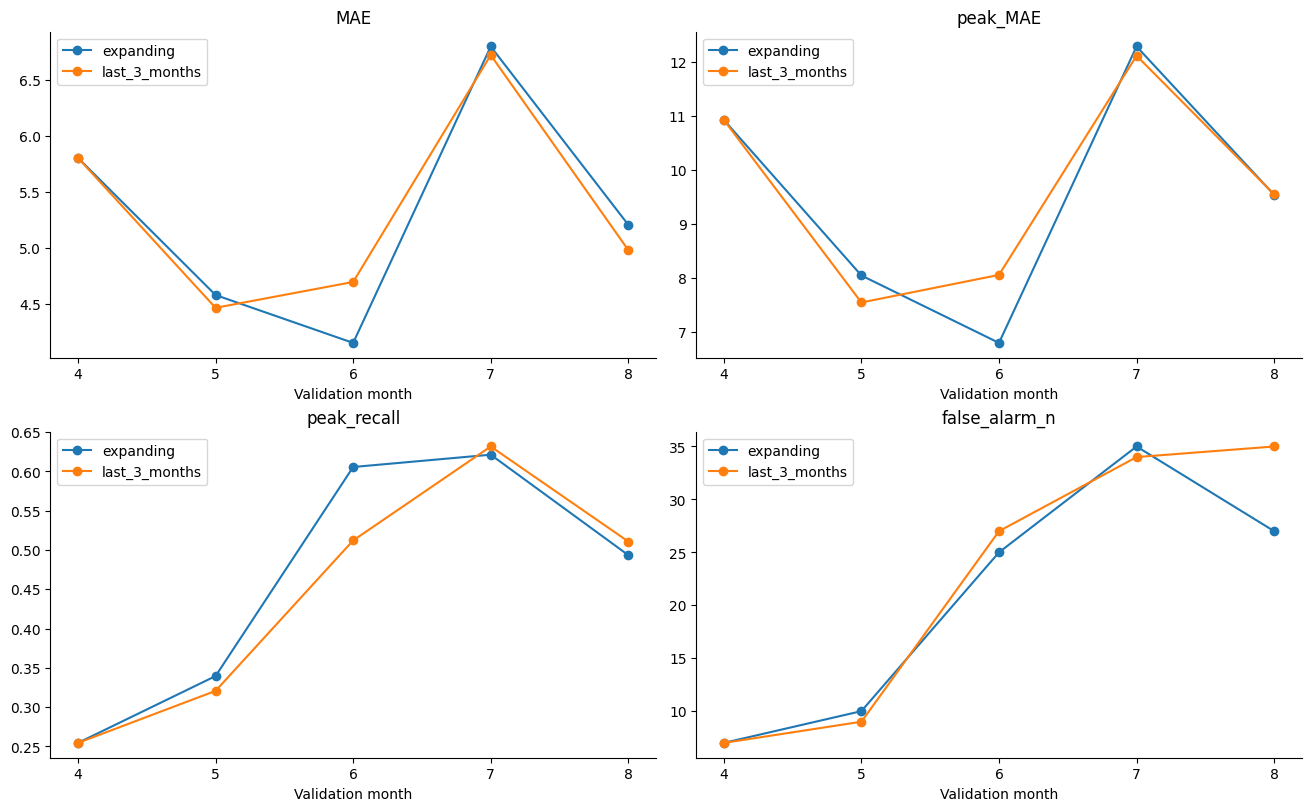

In [10]:
if not sliding["model"].eq("HGB_B").all():
    raise RuntimeError(
        "기존 sliding 결과의 모델이 HGB_B가 아닙니다. 같은 모델끼리 비교해야 하므로 결과를 확인해주세요."
    )
peak_expanding = (
    validation.loc[validation["model"].eq("HGB_B")].copy().assign(window="expanding")
)
peak_sliding = sliding.copy().assign(window="last_3_months")
peak_windows = pd.concat([peak_expanding, peak_sliding], ignore_index=True).sort_values(
    ["fold_month", "window"]
)
display(
    peak_windows[
        [
            "fold_month",
            "window",
            "train_n",
            "MAE",
            "peak_MAE",
            "peak_recall",
            "false_alarm_n",
        ]
    ].round(4)
)
display(
    peak_windows.groupby("window")[["MAE", "peak_MAE", "peak_recall"]].mean().round(4)
)
save_table(peak_windows, PEAK_OUT / "window_monthly.csv", index=False)
fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
for ax, metric in zip(axes.flat, ["MAE", "peak_MAE", "peak_recall", "false_alarm_n"]):
    for window, group in peak_windows.groupby("window"):
        ax.plot(group["fold_month"], group[metric], marker="o", label=window)
    ax.set(title=metric, xlabel="Validation month", xticks=VALIDATION_MONTHS)
    ax.legend()
save_figure(fig, PEAK_OUT / "01_window_monthly.png", dpi=150)


### 11. 고전력 학습 가중치 비교

HGB_B의 고전력 학습 표본에 1·2·3·5의 가중치를 적용한다. 가중치 1은 앞서 계산한 결과를 재사용한다. 가중치는 학습 정답과 학습 P95로만 계산한다.

In [11]:
# 가중치 1의 기존 결과를 재사용하고 2·3·5만 추가 학습한다.
peak_weight_rows = peak_expanding.assign(weight=1).to_dict("records")
peak_baseline_predictions = (
    oof.loc[
        oof["model"].eq("HGB_B") & oof["fold_month"].isin(VALIDATION_MONTHS),
        ["timestamp", "fold_month", "actual", "prediction", "threshold"],
    ]
    .rename(columns={"threshold": "peak_threshold"})
    .copy()
)
peak_baseline_predictions["weight"] = 1
peak_prediction_parts = [peak_baseline_predictions]
for month in VALIDATION_MONTHS:
    start = pd.Timestamp(YEAR, month, 1)
    end = start + pd.offsets.MonthBegin(1)
    train_part = feature_data.loc[feature_data.index < start]
    valid_part = feature_data.loc[
        (feature_data.index >= start) & (feature_data.index < end)
    ]
    threshold = train_part["target"].quantile(0.95)
    for weight in [2, 3, 5]:
        sample_weights = np.where(train_part["target"] >= threshold, float(weight), 1.0)
        estimator = make_model("HGB_B")
        with threadpool_limits(limits=2):
            estimator.fit(
                train_part[FEATURES["B"]],
                train_part["target"],
                sample_weight=sample_weights,
            )
            prediction = np.maximum(estimator.predict(valid_part[FEATURES["B"]]), 0)
        result = metrics(
            valid_part["target"], prediction, threshold, valid_part["weekday"]
        )
        result.update(fold_month=month, weight=weight)
        peak_weight_rows.append(result)
        peak_prediction_parts.append(
            pd.DataFrame(
                {
                    "timestamp": valid_part.index,
                    "fold_month": month,
                    "weight": weight,
                    "actual": valid_part["target"].to_numpy(),
                    "prediction": prediction,
                    "peak_threshold": threshold,
                }
            )
        )
    print(f"{month}월 가중치 실험 완료")
peak_weighted = pd.DataFrame(peak_weight_rows)
peak_oof = pd.concat(peak_prediction_parts, ignore_index=True)
save_table(peak_weighted, PEAK_OUT / "weighted_monthly.csv", index=False)
save_table(peak_oof, PEAK_OUT / "weighted_validation_predictions.csv", index=False)
display(
    peak_weighted[
        [
            "fold_month",
            "weight",
            "MAE",
            "peak_MAE",
            "peak_underprediction",
            "peak_recall",
            "false_alarm_n",
        ]
    ]
    .sort_values(["fold_month", "weight"])
    .round(4)
)


4월 가중치 실험 완료
5월 가중치 실험 완료
6월 가중치 실험 완료
7월 가중치 실험 완료
8월 가중치 실험 완료


,fold_month,weight,MAE,peak_MAE,peak_underprediction,peak_recall,false_alarm_n
0,4,1,5.8044,10.9250,9.9677,0.2545,7
5,4,2,5.8144,10.4471,8.6929,0.2909,14
6,4,3,5.9382,10.2522,8.3126,0.3273,18
7,4,5,5.9501,9.5504,7.5825,0.3818,18
1,5,1,4.5818,8.0438,7.5373,0.3396,10
8,5,2,4.5990,6.5866,5.8483,0.4528,17
9,5,3,4.6854,5.6740,5.0086,0.5283,21
10,5,5,4.7249,5.1634,4.3678,0.5849,27
2,6,1,4.1549,6.7954,6.2037,0.6057,25
11,6,2,4.1415,5.3430,4.7100,0.7317,44


### 12. 가중치 후보 선정과 월별 성능

전체 MAE와 요일 평균 MAE가 기본 모델 대비 5% 이내로 악화되는 후보 중 고전력 MAE가 작은 가중치를 선택한다. 5%는 이번 탐색의 허용 기준이며 실제 운영 비용으로 보정한 최적 기준은 아니다.

검증 결과로 선택한 피크 가중치: 5


,MAE,RMSE,weekday_macro_MAE,peak_MAE,peak_underprediction,peak_recall,alarm_precision,false_alarm_n,MAE_change_pct,eligible
weight,,,,,,,,,,
1,5.3094,7.9634,5.3161,9.5173,8.8917,0.4629,0.7738,20.8,0.0000,True
2,5.2855,7.9803,5.2898,8.4557,7.5379,0.5557,0.7066,34.8,-0.4497,True
3,5.3275,8.0318,5.3294,8.0012,7.0076,0.6040,0.6855,42.0,0.3414,True
5,5.3467,8.0848,5.3458,7.4069,6.3337,0.6560,0.6726,51.2,0.7036,True


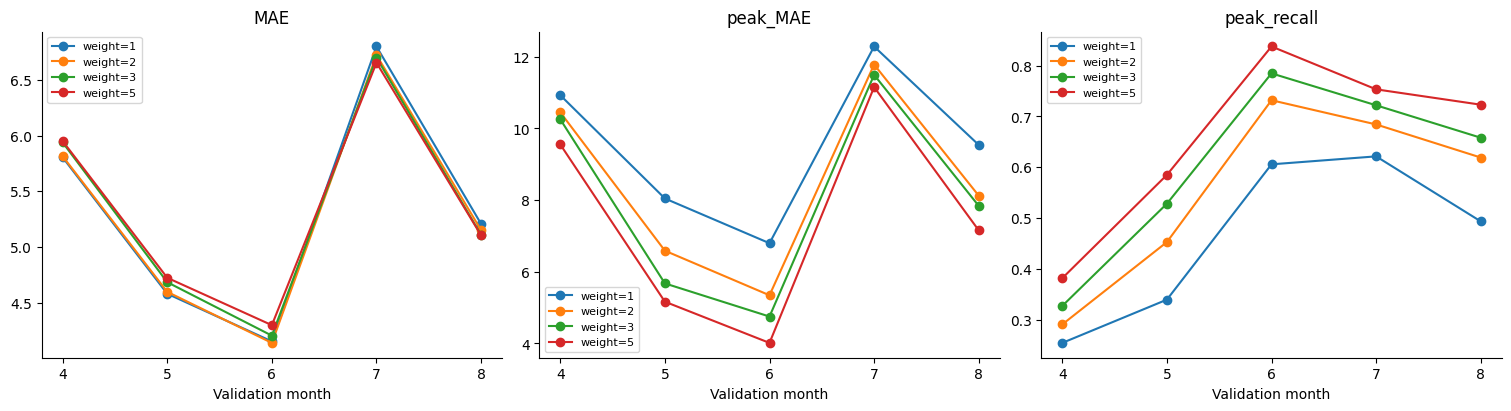

In [12]:
peak_summary = peak_weighted.groupby("weight")[
    [
        "MAE",
        "RMSE",
        "weekday_macro_MAE",
        "peak_MAE",
        "peak_underprediction",
        "peak_recall",
        "alarm_precision",
        "false_alarm_n",
    ]
].mean()
peak_summary["MAE_change_pct"] = (
    peak_summary["MAE"] / peak_summary.loc[1, "MAE"] - 1
) * 100
peak_summary["eligible"] = (
    peak_summary["MAE"] <= peak_summary.loc[1, "MAE"] * 1.05
) & (
    peak_summary["weekday_macro_MAE"] <= peak_summary.loc[1, "weekday_macro_MAE"] * 1.05
)
peak_chosen_weight = int(
    peak_summary.loc[peak_summary["eligible"]].sort_values(["peak_MAE", "MAE"]).index[0]
)
print("검증 결과로 선택한 피크 가중치:", peak_chosen_weight)
display(peak_summary.round(4))
save_table(peak_summary, PEAK_OUT / "weight_summary.csv", index=True)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for ax, metric in zip(axes, ["MAE", "peak_MAE", "peak_recall"]):
    for weight, group in peak_weighted.groupby("weight"):
        group = group.sort_values("fold_month")
        ax.plot(
            group["fold_month"], group[metric], marker="o", label=f"weight={weight}"
        )
    ax.set(title=metric, xlabel="Validation month", xticks=VALIDATION_MONTHS)
    ax.legend(fontsize=8)
save_figure(fig, PEAK_OUT / "02_weight_effect.png", dpi=150)


### 13. 15분 경보 기준의 민감도 분석

예측값이 학습 P95의 85·90·95·100% 이상이면 경고한다. 실제 고전력 정의는 P95의 100%로 유지한다. 비율은 전체 표본 건수를 합산해 계산하며 경보 수는 독립 사건 수가 아닌 15분 표본 수이다.

선택 가중치의 경보 기준별 결과


,n,peak_n,tp,fp,fn,recall,precision,false_positive_rate,alarms_per_day
ratio,,,,,,,,,
0.85,14688,1063,1039,2382,24,0.9774,0.3037,0.1748,22.3595
0.90,14688,1063,1029,1693,34,0.9680,0.3780,0.1243,17.7908
0.95,14688,1063,985,896,78,0.9266,0.5237,0.0658,12.2941
1.00,14688,1063,785,256,278,0.7385,0.7541,0.0188,6.8039


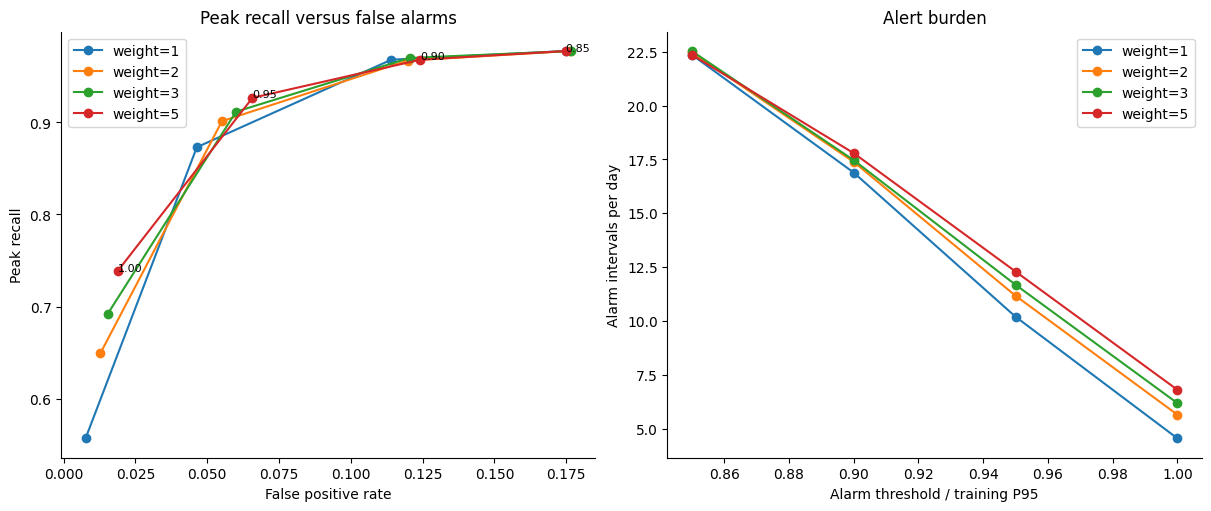

In [13]:
peak_alarm_rows = []
for (weight, month), group in peak_oof.groupby(["weight", "fold_month"]):
    threshold = float(group["peak_threshold"].iloc[0])
    actual_peak = group["actual"].to_numpy() >= threshold
    for ratio in ALARM_RATIOS:
        alarm = group["prediction"].to_numpy() >= threshold * ratio
        tp = int((actual_peak & alarm).sum())
        fp = int((~actual_peak & alarm).sum())
        fn = int((actual_peak & ~alarm).sum())
        peak_alarm_rows.append(
            {
                "weight": weight,
                "fold_month": month,
                "ratio": ratio,
                "peak_threshold": threshold,
                "alarm_threshold": threshold * ratio,
                "n": len(group),
                "peak_n": int(actual_peak.sum()),
                "tp": tp,
                "fp": fp,
                "fn": fn,
            }
        )
peak_alarm_monthly = pd.DataFrame(peak_alarm_rows)
peak_alarm_summary = peak_alarm_monthly.groupby(["weight", "ratio"])[
    ["n", "peak_n", "tp", "fp", "fn"]
].sum()
peak_alarm_summary["recall"] = peak_alarm_summary["tp"] / peak_alarm_summary["peak_n"]
peak_alarm_summary["precision"] = peak_alarm_summary["tp"] / (
    peak_alarm_summary["tp"] + peak_alarm_summary["fp"]
).replace(0, np.nan)
peak_alarm_summary["false_positive_rate"] = peak_alarm_summary["fp"] / (
    peak_alarm_summary["n"] - peak_alarm_summary["peak_n"]
)
peak_alarm_summary["alarms_per_day"] = (
    peak_alarm_summary["tp"] + peak_alarm_summary["fp"]
) / (peak_alarm_summary["n"] / 96)
print("선택 가중치의 경보 기준별 결과")
display(peak_alarm_summary.loc[peak_chosen_weight].round(4))
save_table(peak_alarm_monthly, PEAK_OUT / "alarm_monthly.csv", index=False)
save_table(peak_alarm_summary, PEAK_OUT / "alarm_summary.csv", index=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for weight in PEAK_WEIGHTS:
    group = peak_alarm_summary.loc[weight]
    axes[0].plot(
        group["false_positive_rate"],
        group["recall"],
        marker="o",
        label=f"weight={weight}",
    )
    axes[1].plot(
        group.index, group["alarms_per_day"], marker="o", label=f"weight={weight}"
    )
    if weight == peak_chosen_weight:
        for ratio, row in group.iterrows():
            axes[0].annotate(
                f"{ratio:.2f}", (row["false_positive_rate"], row["recall"]), fontsize=8
            )
axes[0].set(
    title="Peak recall versus false alarms",
    xlabel="False positive rate",
    ylabel="Peak recall",
)
axes[1].set(
    title="Alert burden",
    xlabel="Alarm threshold / training P95",
    ylabel="Alarm intervals per day",
)
for ax in axes:
    ax.legend()
save_figure(fig, PEAK_OUT / "03_alarm_tradeoff.png", dpi=150)


### 14. 가중치 적용 전후의 조건별 오류

기본 가중치와 선택 가중치의 오류를 월·요일·시간·생산 여부 등으로 비교한다. 실제 전력 0 여부는 사후 진단에만 사용한다.

,value,n,MAE,peaks,misses,condition,weight,peak_recall
5,0,14496,5.1000,1027,438,restored,1,0.5735
6,1,192,21.4449,36,33,restored,1,0.0833
7,0,14616,5.2286,1063,471,actual_zero,1,0.5569
8,1,72,22.5868,0,0,actual_zero,1,NaN
40,0,10464,6.4146,1060,470,weekend,1,0.5566
41,1,4224,2.5864,3,1,weekend,1,0.6667
49,0,14496,5.1371,1027,246,restored,5,0.7605
50,1,192,21.3976,36,32,restored,5,0.1111
51,0,14616,5.2669,1063,278,actual_zero,5,0.7385
52,1,72,22.1300,0,0,actual_zero,5,NaN


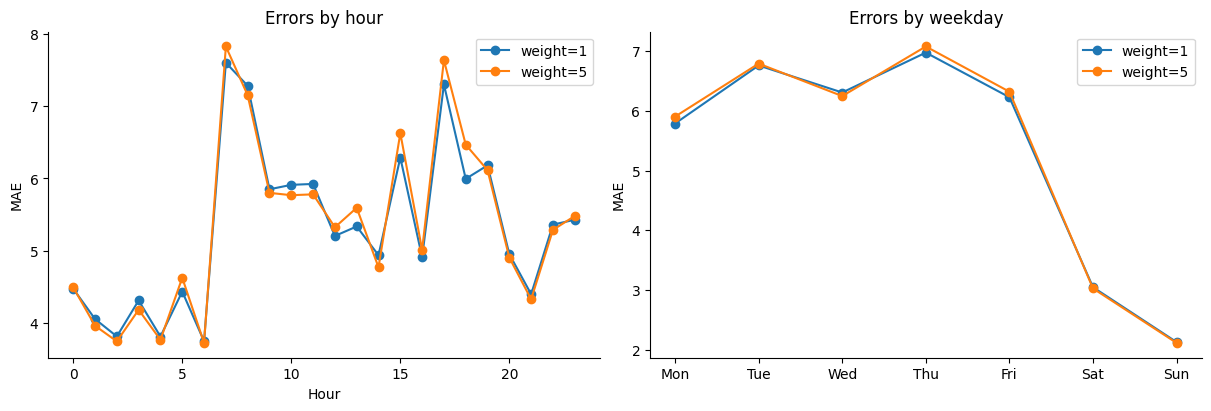

추가 실험 완료
선택한 피크 가중치: 5
결과 저장 위치: /content/output/kai_peak
이번 추가 실험은 4~8월만 사용했으며 9월은 재평가하지 않았습니다.


In [14]:
peak_condition_rows = []
peak_compare_weights = sorted({1, peak_chosen_weight})
for weight in peak_compare_weights:
    group = peak_oof.loc[peak_oof["weight"].eq(weight)].copy()
    index = pd.DatetimeIndex(group["timestamp"])
    group["weekday"] = index.dayofweek
    group["hour"] = index.hour
    group["weekend"] = index.dayofweek >= 5
    group["restored"] = feature_data.loc[index, "hour_restored"].to_numpy()
    group["actual_zero"] = group["actual"].eq(0)
    group["production_positive"] = (
        feature_data.loc[index, "production_known"].to_numpy() > 0
    )
    group["abs_error"] = (group["actual"] - group["prediction"]).abs()
    group["actual_peak"] = group["actual"] >= group["peak_threshold"]
    group["missed_peak"] = group["actual_peak"] & (
        group["prediction"] < group["peak_threshold"]
    )
    for condition in [
        "fold_month",
        "restored",
        "actual_zero",
        "weekday",
        "hour",
        "weekend",
        "production_positive",
    ]:
        result = (
            group.groupby(condition)
            .agg(
                n=("abs_error", "size"),
                MAE=("abs_error", "mean"),
                peaks=("actual_peak", "sum"),
                misses=("missed_peak", "sum"),
            )
            .reset_index()
        )
        result = result.rename(columns={condition: "value"})
        result["condition"] = condition
        result["weight"] = weight
        result["peak_recall"] = 1 - result["misses"] / result["peaks"].replace(
            0, np.nan
        )
        peak_condition_rows.append(result)
peak_conditions = pd.concat(peak_condition_rows, ignore_index=True)
display(
    peak_conditions.loc[
        peak_conditions["condition"].isin(["restored", "actual_zero", "weekend"])
    ].round(4)
)
save_table(peak_conditions, PEAK_OUT / "condition_errors.csv", index=False)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for weight in peak_compare_weights:
    hourly_result = peak_conditions.loc[
        peak_conditions["weight"].eq(weight) & peak_conditions["condition"].eq("hour")
    ].sort_values("value")
    weekday_result = peak_conditions.loc[
        peak_conditions["weight"].eq(weight)
        & peak_conditions["condition"].eq("weekday")
    ].sort_values("value")
    axes[0].plot(
        hourly_result["value"].astype(int),
        hourly_result["MAE"],
        marker="o",
        label=f"weight={weight}",
    )
    axes[1].plot(
        weekday_result["value"].astype(int),
        weekday_result["MAE"],
        marker="o",
        label=f"weight={weight}",
    )
axes[0].set(title="Errors by hour", xlabel="Hour", ylabel="MAE")
axes[1].set(
    title="Errors by weekday",
    xticks=range(7),
    xticklabels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],
    ylabel="MAE",
)
for ax in axes:
    ax.legend()
save_figure(fig, PEAK_OUT / "04_condition_errors.png", dpi=150)
print("추가 실험 완료")
print("선택한 피크 가중치:", peak_chosen_weight)
print("결과 저장 위치:", PEAK_OUT.resolve())
print("이번 추가 실험은 4~8월만 사용했으며 9월은 재평가하지 않았습니다.")


## 4. 다음 한 시간의 네 구간 예측

### 15. 동일 발행 시점의 네 구간 목표값 구성

한 원점에서 다음 네 구간을 각각 예측하도록 정답을 구성한다. pred_15는 [t, t+15분), pred_60은 [t+45분, t+60분)을 나타낸다. 관측 피처는 원점에서 고정하고 미래에 알려진 달력 정보만 변경한다.

In [15]:
# 발행 시점의 관측값은 네 예측 구간에 동일하게 사용한다.
hour_data = feature_data.copy()
for h in HORIZONS:
    hour_data[f"y_{h}"] = feature_data["target"].shift(-(h // 15 - 1))
hour_data = hour_data.dropna(subset=[f"y_{h}" for h in HORIZONS]).copy()
hour_data["label_end"] = hour_data.index + pd.Timedelta(hours=1)


def hour_inputs(data, h):
    """관측 피처는 발행 시점에 고정하고 달력 정보만 미래 구간에 맞춘다."""
    x = data[FEATURES["B"]].copy()
    target_time = data.index + pd.Timedelta(minutes=h - 15)
    x["hour"] = target_time.hour
    x["quarter_id"] = target_time.minute // 15
    x["weekday"] = target_time.dayofweek
    x["weekend"] = (target_time.dayofweek >= 5).astype(int)
    return x


example_t = pd.Timestamp("2021-04-01 10:00")
example = pd.DataFrame(
    {
        "interval_start": [example_t + pd.Timedelta(minutes=h - 15) for h in HORIZONS],
        "interval_end": [example_t + pd.Timedelta(minutes=h) for h in HORIZONS],
        "actual": [hour_data.loc[example_t, f"y_{h}"] for h in HORIZONS],
    },
    index=HORIZONS,
)
display(example)
observed_cols = [
    c for c in FEATURES["B"] if c not in ["hour", "quarter_id", "weekday", "weekend"]
]
assert not any((c.startswith("y_") for c in FEATURES["B"]))
for h in HORIZONS:
    target_t = example_t + pd.Timedelta(minutes=h - 15)
    assert hour_data.loc[example_t, f"y_{h}"] == feature_data.loc[target_t, "target"]
    assert hour_inputs(hour_data.loc[[example_t]], h)[observed_cols].equals(
        hour_inputs(hour_data.loc[[example_t]], 15)[observed_cols]
    )
print("사용 가능 표본:", len(hour_data))


,interval_start,interval_end,actual
15,2021-04-01 10:00:00,2021-04-01 10:15:00,125.0
30,2021-04-01 10:15:00,2021-04-01 10:30:00,141.0
45,2021-04-01 10:30:00,2021-04-01 10:45:00,164.0
60,2021-04-01 10:45:00,2021-04-01 11:00:00,164.0


사용 가능 표본: 23997


### 16. 월별 확장 학습으로 네 구간 동시 예측

각 예측 구간에 대해 HGB 가중치 1·5를 별도로 학습한다. 학습 표본은 네 정답 구간이 평가 월 시작까지 모두 완료된 경우(label_end ≤ start)만 사용한다. 비교 기준 모델도 동일한 원점과 네 구간을 평가한다.

In [16]:
# 네 학습 정답 구간이 모두 평가 월 시작 전에 완료된 표본만 사용한다.
hour_horizon_rows = []
hour_window_rows = []
hour_prediction_parts = []
for month in VALIDATION_MONTHS:
    start = pd.Timestamp(YEAR, month, 1)
    end = start + pd.offsets.MonthBegin(1)
    # 평가 월의 전력이 학습 정답에 포함되지 않도록 한 시간 경계를 적용한다.
    tr = hour_data.loc[hour_data["label_end"] <= start]
    ev = hour_data.loc[(hour_data.index >= start) & (hour_data["label_end"] <= end)]
    assert tr.index.max() + pd.Timedelta(hours=1) <= start
    assert ev.index.max() + pd.Timedelta(hours=1) <= end
    threshold = feature_data.loc[feature_data.index < start, "target"].quantile(0.95)
    actual = ev[[f"y_{h}" for h in HORIZONS]].to_numpy()
    predictions = {
        "Persistence": np.repeat(ev[["lag_1"]].to_numpy(), 4, axis=1),
        "WeeklyNaive": np.column_stack(
            [
                feature_data["target"]
                .shift(672 - (h // 15 - 1))
                .reindex(ev.index)
                .to_numpy()
                for h in HORIZONS
            ]
        ),
    }
    for weight in HOUR_WEIGHTS:
        columns = []
        for h in HORIZONS:
            model = make_model("HGB_B")
            sample_weight = (
                None
                if weight == 1
                else np.where(tr[f"y_{h}"] >= threshold, weight, 1.0)
            )
            with threadpool_limits(limits=2):
                model.fit(hour_inputs(tr, h), tr[f"y_{h}"], sample_weight=sample_weight)
                columns.append(np.maximum(model.predict(hour_inputs(ev, h)), 0))
        predictions[f"HGB_w{weight}"] = np.column_stack(columns)
    for name, pred in predictions.items():
        assert pred.shape == actual.shape
        assert np.isfinite(pred).all()
        for j, h in enumerate(HORIZONS):
            target_weekday = (ev.index + pd.Timedelta(minutes=h - 15)).dayofweek
            result = metrics(actual[:, j], pred[:, j], threshold, target_weekday)
            result.update(model=name, fold_month=month, horizon_min=h, train_n=len(tr))
            hour_horizon_rows.append(result)
        actual_max = actual.max(axis=1)
        pred_max = pred.max(axis=1)
        evaluation_masks = [
            ("every_15min", np.ones(len(ev), dtype=bool)),
            ("hourly_origins", ev.index.minute == 0),
        ]
        for cadence, mask in evaluation_masks:
            result = metrics(
                actual_max[mask],
                pred_max[mask],
                threshold,
                ev["weekday"].to_numpy()[mask],
            )
            result.update(model=name, fold_month=month, cadence=cadence)
            hour_window_rows.append(result)
        part = pd.DataFrame(
            {
                "timestamp": ev.index,
                "fold_month": month,
                "model": name,
                "threshold": threshold,
                "actual_max": actual_max,
                "predicted_max": pred_max,
            }
        )
        for j, h in enumerate(HORIZONS):
            part[f"actual_{h}"] = actual[:, j]
            part[f"pred_{h}"] = pred[:, j]
        hour_prediction_parts.append(part)
    print(f"{month}월 완료: 학습 {len(tr)}, 검증 {len(ev)}, 피크 기준 {threshold}")
hour_horizons = pd.DataFrame(hour_horizon_rows)
hour_windows = pd.DataFrame(hour_window_rows)
hour_predictions = pd.concat(hour_prediction_parts, ignore_index=True)
save_table(hour_horizons, HOUR_OUT / "horizon_monthly.csv", index=False)
save_table(hour_windows, HOUR_OUT / "hour_max_monthly.csv", index=False)
save_table(hour_predictions, HOUR_OUT / "hour_predictions.csv", index=False)


4월 완료: 학습 7965, 검증 2877, 피크 기준 178.0
5월 완료: 학습 10845, 검증 2973, 피크 기준 177.0
6월 완료: 학습 13821, 검증 2877, 피크 기준 175.0
7월 완료: 학습 16701, 검증 2973, 피크 기준 176.0
8월 완료: 학습 19677, 검증 2973, 피크 기준 179.0


### 17. 예측 구간·평가 월별 정확도 시각화

구간별 오차와 한 시간 최대값의 월별 오차를 비교한다. 구간 끝까지의 예측 거리가 길어질수록 오차가 어떻게 달라지는지 확인한다. 오차 요약은 월별 지표의 단순 평균이다.

구간별 성능: 월별 지표 평균
다음 1시간 최대값 성능: 월별 지표 평균


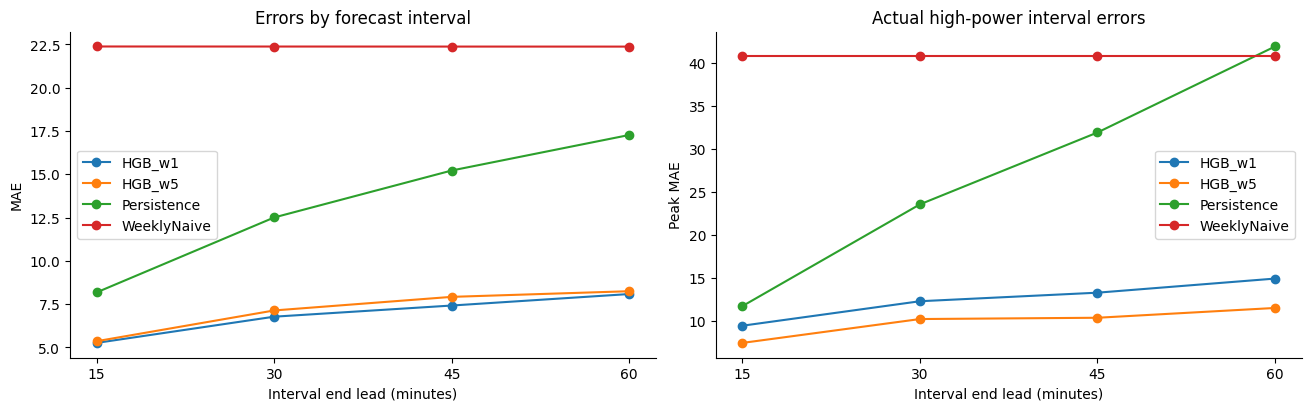

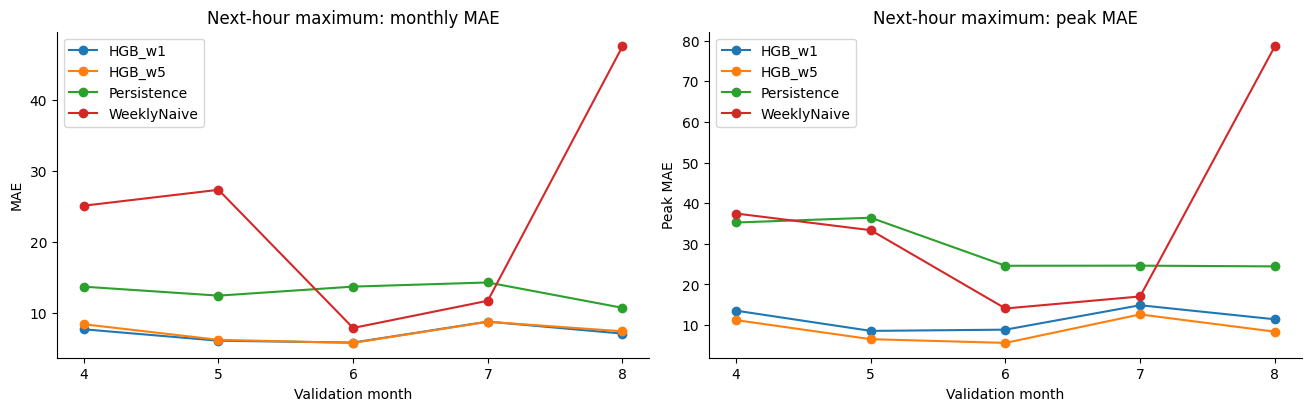

In [17]:
hour_horizon_summary = hour_horizons.groupby(["model", "horizon_min"])[
    ["MAE", "RMSE", "peak_MAE", "peak_underprediction", "peak_recall"]
].mean()
hour_max_summary = hour_windows.groupby(["cadence", "model"])[
    [
        "MAE",
        "RMSE",
        "peak_MAE",
        "peak_underprediction",
        "peak_recall",
        "alarm_precision",
        "false_alarm_n",
    ]
].mean()
print("구간별 성능: 월별 지표 평균")
print("다음 1시간 최대값 성능: 월별 지표 평균")
save_table(hour_horizon_summary, HOUR_OUT / "horizon_summary.csv", index=True)
save_table(hour_max_summary, HOUR_OUT / "hour_max_summary.csv", index=True)
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
for name, group in hour_horizon_summary.groupby(level="model"):
    group = group.droplevel("model")
    axes[0].plot(group.index, group["MAE"], marker="o", label=name)
    axes[1].plot(group.index, group["peak_MAE"], marker="o", label=name)
axes[0].set(
    title="Errors by forecast interval",
    xlabel="Interval end lead (minutes)",
    ylabel="MAE",
)
axes[1].set(
    title="Actual high-power interval errors",
    xlabel="Interval end lead (minutes)",
    ylabel="Peak MAE",
)
for ax in axes:
    ax.set_xticks(HORIZONS)
    ax.legend()
save_figure(fig, HOUR_OUT / "01_horizon_errors.png", dpi=150)
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
rolling_results = hour_windows.loc[hour_windows["cadence"].eq("every_15min")]
for name, group in rolling_results.groupby("model"):
    axes[0].plot(group["fold_month"], group["MAE"], marker="o", label=name)
    axes[1].plot(group["fold_month"], group["peak_MAE"], marker="o", label=name)
axes[0].set(
    title="Next-hour maximum: monthly MAE", xlabel="Validation month", ylabel="MAE"
)
axes[1].set(
    title="Next-hour maximum: peak MAE", xlabel="Validation month", ylabel="Peak MAE"
)
for ax in axes:
    ax.set_xticks(VALIDATION_MONTHS)
    ax.legend()
save_figure(fig, HOUR_OUT / "02_hour_max_monthly.png", dpi=150)


### 18. 한 시간 경보의 탐지율과 오경보

모든 15분 원점과 정시 원점을 구분하여 월별 혼동행렬을 한 번 계산한다. TP는 탐지, FN은 미탐지, FP는 오경보, TN은 정상 무경보이다. 월별 건수를 합산한 탐지율·정밀도와 오경보율을 제시한다.

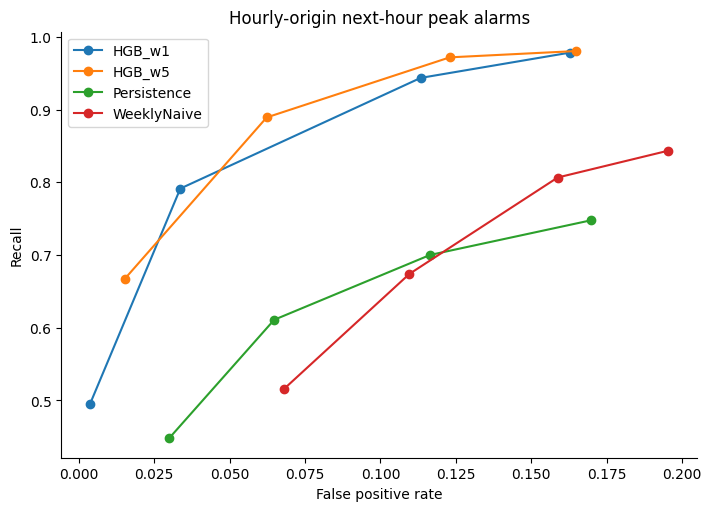

In [18]:
# 월별 혼동행렬을 계산한 뒤 전체 건수를 합산한다.
hour_alarm_rows = []
for cadence in ["every_15min", "hourly_origins"]:
    data = hour_predictions
    if cadence == "hourly_origins":
        data = data.loc[data["timestamp"].dt.minute.eq(0)]
    for (name, month), group in data.groupby(["model", "fold_month"]):
        high = group["actual_max"].to_numpy() >= group["threshold"].to_numpy()
        for ratio in ALARM_RATIOS:
            alarm = (
                group["predicted_max"].to_numpy()
                >= group["threshold"].to_numpy() * ratio
            )
            hour_alarm_rows.append(
                {
                    "cadence": cadence,
                    "model": name,
                    "fold_month": month,
                    "ratio": ratio,
                    "n": len(group),
                    "peak_n": int(high.sum()),
                    "tp": int((high & alarm).sum()),
                    "fp": int((~high & alarm).sum()),
                    "fn": int((high & ~alarm).sum()),
                    "tn": int((~high & ~alarm).sum()),
                }
            )
hour_alarm_monthly = pd.DataFrame(hour_alarm_rows)
hour_alarms = (
    hour_alarm_monthly.groupby(["cadence", "model", "ratio"])[
        ["n", "peak_n", "tp", "fp", "fn", "tn"]
    ]
    .sum()
    .reset_index()
)
hour_alarms["recall"] = hour_alarms["tp"] / hour_alarms["peak_n"].replace(0, np.nan)
hour_alarms["precision"] = hour_alarms["tp"] / (
    hour_alarms["tp"] + hour_alarms["fp"]
).replace(0, np.nan)
hour_alarms["false_positive_rate"] = hour_alarms["fp"] / (
    hour_alarms["n"] - hour_alarms["peak_n"]
).replace(0, np.nan)
hour_alarms["alarm_fraction"] = (hour_alarms["tp"] + hour_alarms["fp"]) / hour_alarms[
    "n"
]
save_table(hour_alarms, HOUR_OUT / "hour_alarm_tradeoff.csv")
save_table(hour_alarm_monthly, HOUR_OUT / "hour_alarm_monthly.csv")
fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
for name, group in hour_alarms.loc[hour_alarms["cadence"].eq("hourly_origins")].groupby(
    "model"
):
    ax.plot(group["false_positive_rate"], group["recall"], marker="o", label=name)
ax.set(
    title="Hourly-origin next-hour peak alarms",
    xlabel="False positive rate",
    ylabel="Recall",
)
ax.legend()
save_figure(fig, HOUR_OUT / "03_hour_alarm_tradeoff.png", dpi=150)


### 19. 한 시간 예측의 오류 조건과 예측 사례

발행 시각·요일·주말·복원 날짜·생산 여부 등의 최대값 오류를 비교하고, 한 발행 시점의 네 예측값을 실제값과 함께 표시한다.

,value,n,MAE,condition,model
36,0,10452,8.0284,weekend,HGB_w1
37,1,4221,4.6951,weekend,HGB_w1
38,0,14481,6.8228,restored_origin,HGB_w1
39,1,192,25.6777,restored_origin,HGB_w1
40,0,14598,6.9784,any_actual_zero,HGB_w1
41,1,75,24.7937,any_actual_zero,HGB_w1
80,0,10452,7.9650,weekend,HGB_w5
81,1,4221,5.6004,weekend,HGB_w5
82,0,14481,7.0234,restored_origin,HGB_w5
83,1,192,26.9985,restored_origin,HGB_w5


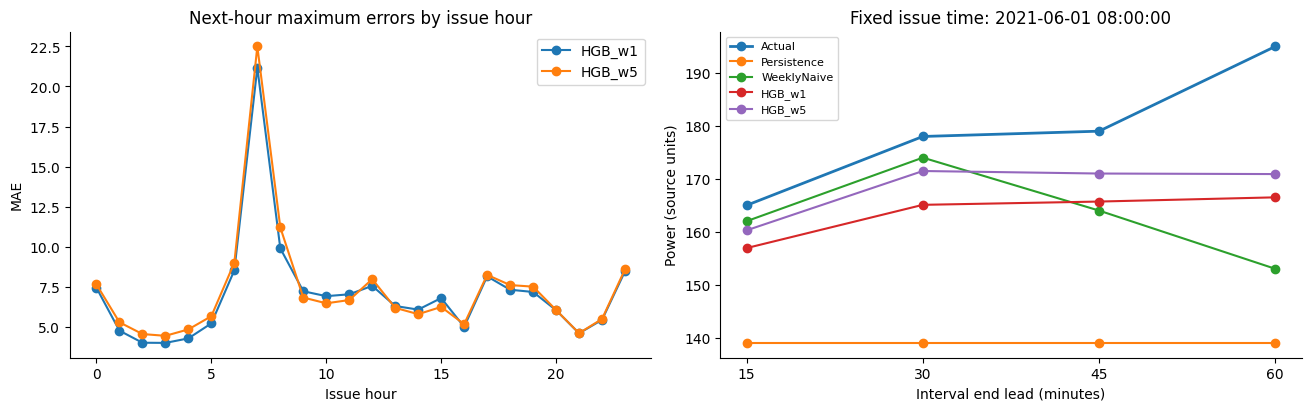

1시간 예측 실험 완료
결과 저장 위치: /content/output/kai_hour
4~8월 검증만 사용했으며 9월은 재평가하지 않았습니다.


In [19]:
hour_condition_rows = []
hgb_predictions = hour_predictions.loc[hour_predictions["model"].str.startswith("HGB")]
for name, group in hgb_predictions.groupby("model"):
    group = group.copy()
    index = pd.DatetimeIndex(group["timestamp"])
    group["weekday"] = index.dayofweek
    group["hour"] = index.hour
    group["weekend"] = index.dayofweek >= 5
    group["restored_origin"] = feature_data.loc[index, "hour_restored"].to_numpy()
    group["any_actual_zero"] = (
        group[[f"actual_{h}" for h in HORIZONS]].eq(0).any(axis=1)
    )
    group["production_positive"] = (
        feature_data.loc[index, "production_known"].to_numpy() > 0
    )
    group["error"] = (group["actual_max"] - group["predicted_max"]).abs()
    for condition in [
        "fold_month",
        "weekday",
        "hour",
        "weekend",
        "restored_origin",
        "any_actual_zero",
        "production_positive",
    ]:
        result = (
            group.groupby(condition)
            .agg(n=("error", "size"), MAE=("error", "mean"))
            .reset_index()
        )
        result = result.rename(columns={condition: "value"})
        result["condition"] = condition
        result["model"] = name
        hour_condition_rows.append(result)
hour_conditions = pd.concat(hour_condition_rows, ignore_index=True)
save_table(hour_conditions, HOUR_OUT / "hour_condition_errors.csv", index=False)
display(
    hour_conditions.loc[
        hour_conditions["condition"].isin(
            ["restored_origin", "any_actual_zero", "weekend"]
        )
    ].round(4)
)
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
hourly_conditions = hour_conditions.loc[hour_conditions["condition"].eq("hour")]
for name, group in hourly_conditions.groupby("model"):
    axes[0].plot(group["value"].astype(int), group["MAE"], marker="o", label=name)
axes[0].set(
    title="Next-hour maximum errors by issue hour", xlabel="Issue hour", ylabel="MAE"
)
axes[0].legend()
origin = pd.Timestamp("2021-06-01 08:00")
example = hour_predictions.loc[hour_predictions["timestamp"].eq(origin)]
actual = example.iloc[0][[f"actual_{h}" for h in HORIZONS]].to_numpy(dtype=float)
axes[1].plot(HORIZONS, actual, marker="o", linewidth=2, label="Actual")
for _, row in example.iterrows():
    axes[1].plot(
        HORIZONS,
        row[[f"pred_{h}" for h in HORIZONS]].to_numpy(dtype=float),
        marker="o",
        label=row["model"],
    )
axes[1].set(
    title=f"Fixed issue time: {origin}",
    xlabel="Interval end lead (minutes)",
    ylabel="Power (source units)",
    xticks=HORIZONS,
)
axes[1].legend(fontsize=8)
save_figure(fig, HOUR_OUT / "04_hour_conditions_example.png", dpi=150)
print("1시간 예측 실험 완료")
print("결과 저장 위치:", HOUR_OUT.resolve())
print("4~8월 검증만 사용했으며 9월은 재평가하지 않았습니다.")


## 5. 가정에 따른 부하 이동 시뮬레이션

### 20. 실제 고전력 발생 조건의 사후 분석

실제 고전력 구간이 발생하는 시간·요일·생산 조건과 급상승 조건을 분석한다. 현재 시간 생산량과 실제 상승량은 이미 관측된 자료를 설명하기 위한 값이며 실행 시점의 조정 조건에 넣지 않는다.

큰 상승 기준: 36.0


,value,n,peaks,mean_power,max_power,peak_rate,peak_share,condition
36,0,10464,1060,117.5065,222.0,0.1013,0.9972,weekend
37,1,4224,3,34.1849,184.0,0.0007,0.0028,weekend
38,0,5780,47,37.2583,202.0,0.0081,0.0442,production_positive
39,1,8908,1016,130.0665,222.0,0.1141,0.9558,production_positive
40,0,14496,1027,92.9845,222.0,0.0708,0.9661,restored
41,1,192,36,135.8385,202.0,0.1875,0.0339,restored
42,0,14366,1002,92.1444,222.0,0.0697,0.9426,large_rise
43,1,322,61,156.0217,222.0,0.1894,0.0574,large_rise


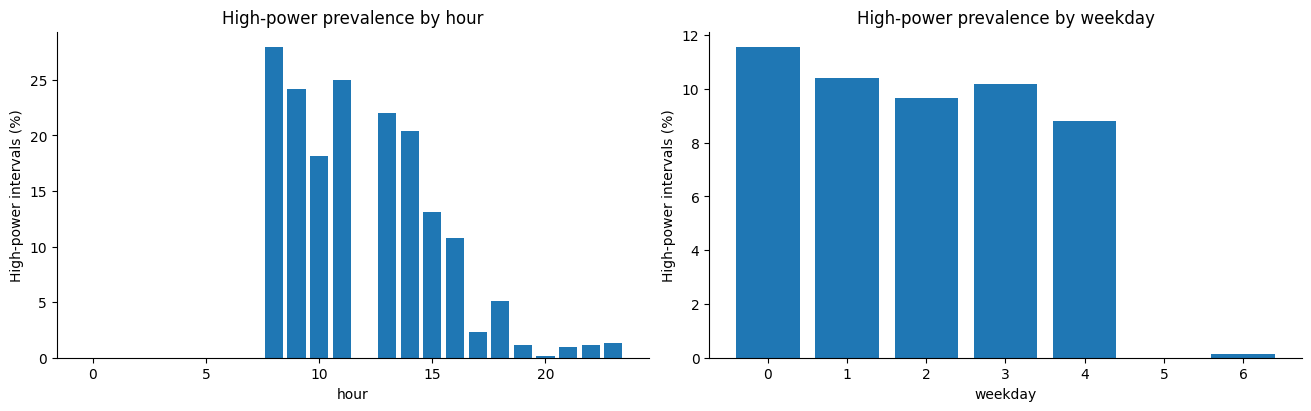

In [20]:
# 현재 생산량과 실제 상승량은 사후 조건 분석용이다.
peak_diagnosis = feature_data.loc[
    (feature_data.index >= "2021-04-01") & (feature_data.index < "2021-09-01")
].copy()
peak_diagnosis["fold_month"] = peak_diagnosis.index.month
thresholds = {
    month: feature_data.loc[
        feature_data.index < pd.Timestamp(YEAR, month, 1), "target"
    ].quantile(0.95)
    for month in VALIDATION_MONTHS
}
peak_diagnosis["threshold"] = peak_diagnosis["fold_month"].map(thresholds)
peak_diagnosis["peak"] = peak_diagnosis["target"] >= peak_diagnosis["threshold"]
production_now = hourly.set_index("timestamp")["생산량"]
peak_diagnosis["current_production"] = production_now.reindex(
    peak_diagnosis.index.floor("h")
).to_numpy()
peak_diagnosis["production_positive"] = peak_diagnosis["current_production"] > 0
peak_diagnosis["restored"] = peak_diagnosis["hour_restored"]
peak_diagnosis["weekend"] = peak_diagnosis.index.dayofweek >= 5
peak_diagnosis["hour"] = peak_diagnosis.index.hour
peak_diagnosis["weekday"] = peak_diagnosis.index.dayofweek
peak_diagnosis["observed_ramp"] = peak_diagnosis["target"] - peak_diagnosis["lag_1"]
initial = feature_data.loc[feature_data.index < "2021-04-01"]
ramps = initial["target"] - initial["lag_1"]
ramp_cutoff = ramps.loc[ramps > 0].quantile(0.95)
peak_diagnosis["large_rise"] = peak_diagnosis["observed_ramp"] >= ramp_cutoff
peak_condition_parts = []
for condition in [
    "fold_month",
    "weekday",
    "hour",
    "weekend",
    "production_positive",
    "restored",
    "large_rise",
]:
    result = (
        peak_diagnosis.groupby(condition)
        .agg(
            n=("peak", "size"),
            peaks=("peak", "sum"),
            mean_power=("target", "mean"),
            max_power=("target", "max"),
        )
        .reset_index()
    )
    result = result.rename(columns={condition: "value"})
    result["peak_rate"] = result["peaks"] / result["n"]
    result["peak_share"] = result["peaks"] / peak_diagnosis["peak"].sum()
    result["condition"] = condition
    peak_condition_parts.append(result)
peak_condition_summary = pd.concat(peak_condition_parts, ignore_index=True)
print("큰 상승 기준:", ramp_cutoff)
display(
    peak_condition_summary.loc[
        peak_condition_summary["condition"].isin(
            ["weekend", "production_positive", "restored", "large_rise"]
        )
    ].round(4)
)
save_table(peak_condition_summary, OPT_OUT / "peak_conditions.csv", index=False)
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
for ax, condition in zip(axes, ["hour", "weekday"]):
    result = peak_condition_summary.loc[
        peak_condition_summary["condition"].eq(condition)
    ]
    ax.bar(result["value"].astype(int), result["peak_rate"] * 100)
    ax.set(
        title=f"High-power prevalence by {condition}",
        xlabel=condition,
        ylabel="High-power intervals (%)",
    )
save_figure(fig, OPT_OUT / "01_peak_conditions.png", dpi=150)


### 21. 가상 부하 배정의 목적함수와 제약

네 구간의 예측 부하 중 eta 비율이 이동 가능하다고 가정한다. 목적함수는 정규화한 최대 부하 z/P0와 이동량 패널티 0.2×M/S0의 합이다. 원래 부하량 보존, 이동 범위, 수신 구간 순증가 한도를 제약으로 둔다. 이는 실제 생산량·설비 작업의 배정 모델이 아닌 전력 부하 대리량의 가상 배정이다.

In [ ]:
# 생산 작업 대신 이동 가능한 전력 대리량을 배정하는 가상 모형이다.
def optimize_hour_profile(
    prediction, eta=0.2, max_shift=1, penalty=0.2, receive_cap=0.2, eligible=True
):
    """가정한 이동 가능 부하를 선형계획으로 배정하여 예측 최대값을 낮춘다."""
    p = np.asarray(prediction, dtype=float)
    assert len(p) == 4
    assert np.isfinite(p).all()
    assert (p >= 0).all()
    # 예측 부하를 고정 부분과 이동 가능한 대리량으로 분리한다.
    movable = eta * p if eligible else np.zeros(4)
    fixed = p - movable
    if movable.sum() < 1e-09:
        return {
            "after": p.copy(),
            "flow": np.diag(movable),
            "movable": movable,
            "moved": 0.0,
            "moved_fraction": 0.0,
            "objective": float(p.max() / max(p.max(), 1e-09)),
            "status": "no_adjustable_load",
        }
    pairs = [(i, j) for i in range(4) for j in range(4) if abs(i - j) <= max_shift]
    count = len(pairs)
    P0 = max(p.max(), 1e-09)
    S = max(p.sum(), 1e-09)
    # 변수의 마지막 항은 최대 부하 z이며, 비대각 배정량에만 이동 패널티를 둔다.
    c = np.array([penalty / S if i != j else 0.0 for i, j in pairs] + [1 / P0])
    # 등식 제약: 각 원래 구간의 이동 가능 대리량을 모두 배정한다.
    Aeq = np.zeros((4, count + 1))
    for k, (i, j) in enumerate(pairs):
        Aeq[i, k] = 1
    # 앞 네 행은 최대값 제한, 뒤 네 행은 수신 구간의 순증가 제한이다.
    Aub = np.zeros((8, count + 1))
    bub = np.r_[-fixed, p + receive_cap * p.mean() - fixed]
    for k, (i, j) in enumerate(pairs):
        Aub[j, k] = 1
        Aub[4 + j, k] = 1
    Aub[:4, -1] = -1
    result = linprog(
        c,
        A_ub=Aub,
        b_ub=bub,
        A_eq=Aeq,
        b_eq=movable,
        bounds=[(0, None)] * (count + 1),
        method="highs",
    )
    if not result.success:
        raise RuntimeError(result.message)
    flow = np.zeros((4, 4))
    for k, (i, j) in enumerate(pairs):
        flow[i, j] = result.x[k]
    after = fixed + flow.sum(axis=0)
    moved = flow.sum() - np.trace(flow)
    assert np.allclose(flow.sum(axis=1), movable, atol=1e-06)
    assert np.isclose(after.sum(), p.sum(), atol=1e-06)
    assert np.all(after >= fixed - 1e-06)
    assert np.all(after <= p + receive_cap * p.mean() + 1e-06)
    distance = np.abs(np.arange(4)[:, None] - np.arange(4)[None, :])
    assert np.all(flow[distance > max_shift] < 1e-06)
    assert after.max() <= p.max() + 1e-06
    return {
        "after": after,
        "flow": flow,
        "movable": movable,
        "moved": float(moved),
        "moved_fraction": float(moved / S),
        "objective": float(result.fun),
        "status": "optimized",
    }


trial = np.array([100.0, 200.0, 100.0, 100.0])
assert np.allclose(optimize_hour_profile(trial, eta=0)["after"], trial)
trial_plan = optimize_hour_profile(trial, eta=0.2, max_shift=1)
assert trial_plan["after"].max() < trial.max()
print("조정 전:", trial)
print("조정 후:", trial_plan["after"])


조정 전: [100. 200. 100. 100.]
조정 후: [115. 160. 125. 100.]


### 22. 이동 가능 비율·범위별 가상 시뮬레이션

이동 가능 비율 0·10·20·30%와 이동 범위 15·30분의 기존 시나리오를 유지한다. 최근 완료 생산량이 양수이면 이동 가능한 작업이 있다고 가정한다. 계획 변화량을 실제값에 동일하게 더한 조건부 재생을 수행한다. 재생 가능 여부는 미래 실제값을 사용한 사후 점검이므로 실행 조건으로 사용할 수 없다.

In [22]:
# 실제값을 이용한 재생 가능 여부는 사후 평가에만 사용한다.
SCENARIOS = [
    dict(name="No_change", eta=0.0, max_shift=1),
    dict(name="10pct_15min", eta=0.1, max_shift=1),
    dict(name="20pct_15min", eta=0.2, max_shift=1),
    dict(name="20pct_30min", eta=0.2, max_shift=2),
    dict(name="30pct_30min", eta=0.3, max_shift=2),
]
opt_cases = hour_predictions.loc[hour_predictions["model"].eq("HGB_w5")].copy()
opt_cases = opt_cases.loc[
    pd.DatetimeIndex(opt_cases["timestamp"]).minute == 0
].sort_values("timestamp")
opt_records = []
opt_profile_parts = []
for scenario in SCENARIOS:
    for _, row in opt_cases.iterrows():
        t = pd.Timestamp(row["timestamp"])
        p = row[[f"pred_{h}" for h in HORIZONS]].to_numpy(dtype=float)
        y = row[[f"actual_{h}" for h in HORIZONS]].to_numpy(dtype=float)
        eligible = bool(feature_data.loc[t, "production_known"] > 0)
        plan = optimize_hour_profile(
            p, eta=scenario["eta"], max_shift=scenario["max_shift"], eligible=eligible
        )
        delta = plan["after"] - p
        outflow = plan["movable"] - np.diag(plan["flow"])
        replay = y + delta
        available = scenario["eta"] * y if eligible else np.zeros(4)
        replay_feasible = bool(
            (outflow <= available + 1e-06).all()
            and (replay >= -1e-06).all()
            and (replay <= y + 0.2 * y.mean() + 1e-06).all()
        )
        opt_records.append(
            {
                "timestamp": t,
                "fold_month": int(row["fold_month"]),
                "scenario": scenario["name"],
                "eta": scenario["eta"],
                "max_shift": scenario["max_shift"],
                "eligible": eligible,
                "pred_before": p.max(),
                "pred_after": plan["after"].max(),
                "pred_reduction_pct": 100
                * (p.max() - plan["after"].max())
                / max(p.max(), 1e-09),
                "moved_fraction": plan["moved_fraction"],
                "objective": plan["objective"],
                "actual_before": y.max(),
                "replay_after": replay.max() if replay_feasible else np.nan,
                "replay_feasible": replay_feasible,
                "replay_reduction_pct": (
                    100 * (y.max() - replay.max()) / max(y.max(), 1e-09)
                    if replay_feasible
                    else np.nan
                ),
            }
        )
        opt_profile_parts.append(
            pd.DataFrame(
                {
                    "timestamp": t,
                    "scenario": scenario["name"],
                    "horizon_min": HORIZONS,
                    "prediction": p,
                    "planned": plan["after"],
                    "actual": y,
                    "conditional_replay": (
                        replay if replay_feasible else np.full(4, np.nan)
                    ),
                }
            )
        )
    print("시나리오 완료:", scenario["name"])
opt_results = pd.DataFrame(opt_records)
opt_profiles = pd.concat(opt_profile_parts, ignore_index=True)
save_table(opt_results, OPT_OUT / "optimization_cases.csv", index=False)
save_table(opt_profiles, OPT_OUT / "optimization_profiles.csv", index=False)


시나리오 완료: No_change
시나리오 완료: 10pct_15min
시나리오 완료: 20pct_15min
시나리오 완료: 20pct_30min
시나리오 완료: 30pct_30min


### 23. 예측 기반 배정 계획의 변화

가상의 배정 후 예측 최대값 변화와 이동량을 전체 원점 및 이동 가능하다고 가정한 원점으로 구분하여 요약한다. 한 시간 내 최대값 감소율은 월 최대수요 감소율이나 요금 절감률과 다르다.

전체 원점 기준


,n,eligible_n,mean_pred_peak_before,mean_pred_peak_after,mean_pred_peak_reduction_pct,mean_moved_fraction,replay_feasible_rate
scenario,,,,,,,
No_change,3672,2226,100.2305,100.2305,0.0000,0.0000,1.0000
10pct_15min,3672,2226,100.2305,97.0235,2.4917,0.0189,0.9039
20pct_15min,3672,2226,100.2305,96.5053,2.9088,0.0242,0.9733
20pct_30min,3672,2226,100.2305,96.4417,2.9568,0.0156,0.9864
30pct_30min,3672,2226,100.2305,96.4307,2.9769,0.0157,0.9880


조정 가능하다고 가정한 원점만


,n,mean_pred_peak_reduction_pct,mean_moved_fraction,replay_feasible_rate
scenario,,,,
No_change,2226,0.0000,0.0000,1.0000
10pct_15min,2226,4.1103,0.0312,0.8414
20pct_15min,2226,4.7983,0.0399,0.9560
20pct_30min,2226,4.8774,0.0257,0.9775
30pct_30min,2226,4.9107,0.0259,0.9802


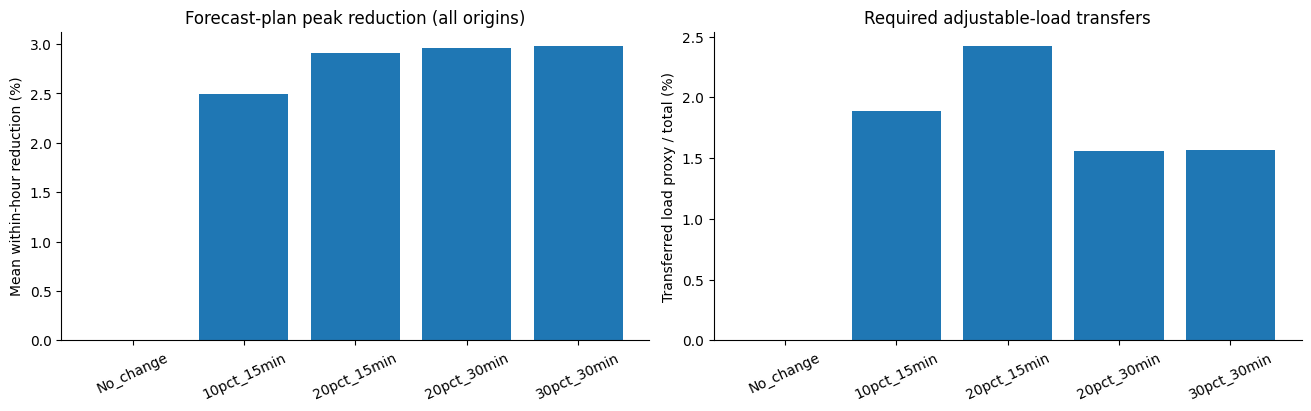

In [23]:
opt_summary = opt_results.groupby("scenario", sort=False).agg(
    n=("timestamp", "size"),
    eligible_n=("eligible", "sum"),
    mean_pred_peak_before=("pred_before", "mean"),
    mean_pred_peak_after=("pred_after", "mean"),
    mean_pred_peak_reduction_pct=("pred_reduction_pct", "mean"),
    mean_moved_fraction=("moved_fraction", "mean"),
    replay_feasible_rate=("replay_feasible", "mean"),
)
print("전체 원점 기준")
display(opt_summary.round(4))
opt_active_summary = (
    opt_results.loc[opt_results["eligible"]]
    .groupby("scenario", sort=False)
    .agg(
        n=("timestamp", "size"),
        mean_pred_peak_reduction_pct=("pred_reduction_pct", "mean"),
        mean_moved_fraction=("moved_fraction", "mean"),
        replay_feasible_rate=("replay_feasible", "mean"),
    )
)
print("조정 가능하다고 가정한 원점만")
display(opt_active_summary.round(4))
save_table(opt_summary, OPT_OUT / "optimization_summary.csv", index=True)
save_table(opt_active_summary, OPT_OUT / "optimization_active_summary.csv", index=True)
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
axes[0].bar(opt_summary.index, opt_summary["mean_pred_peak_reduction_pct"])
axes[0].set(
    title="Forecast-plan peak reduction (all origins)",
    ylabel="Mean within-hour reduction (%)",
)
axes[1].bar(opt_summary.index, opt_summary["mean_moved_fraction"] * 100)
axes[1].set(
    title="Required adjustable-load transfers",
    ylabel="Transferred load proxy / total (%)",
)
for ax in axes:
    ax.tick_params(axis="x", rotation=25)
save_figure(fig, OPT_OUT / "02_scenario_sensitivity.png", dpi=150)


### 24. 조건부 재생 평가와 배정 예시

사후 재생 가능 조건을 만족한 표본에서 실제 관측 최대값과 가상 재생 최대값을 비교한다. 제외 표본 수를 함께 제시한다. 한 사례의 배정 행렬은 원래 구간과 수신 구간 사이의 대리 부하 배정을 보여준다.

같은 가용 표본끼리 비교한 조건부 재생 결과
실측 절감 결과가 아닙니다.


,feasible_n,mean_actual_before,mean_replay_after,mean_replay_reduction_pct,peak_increase_rate,excluded_n
scenario,,,,,,
No_change,3672,101.1405,101.1405,0.0000,0.0000,0
10pct_15min,3319,98.4730,97.6037,0.6201,0.2031,353
20pct_15min,3574,100.8858,99.5907,0.8819,0.2071,98
20pct_30min,3622,101.4934,99.9848,1.0239,0.2043,50
30pct_30min,3628,101.4928,99.9936,1.0152,0.2051,44


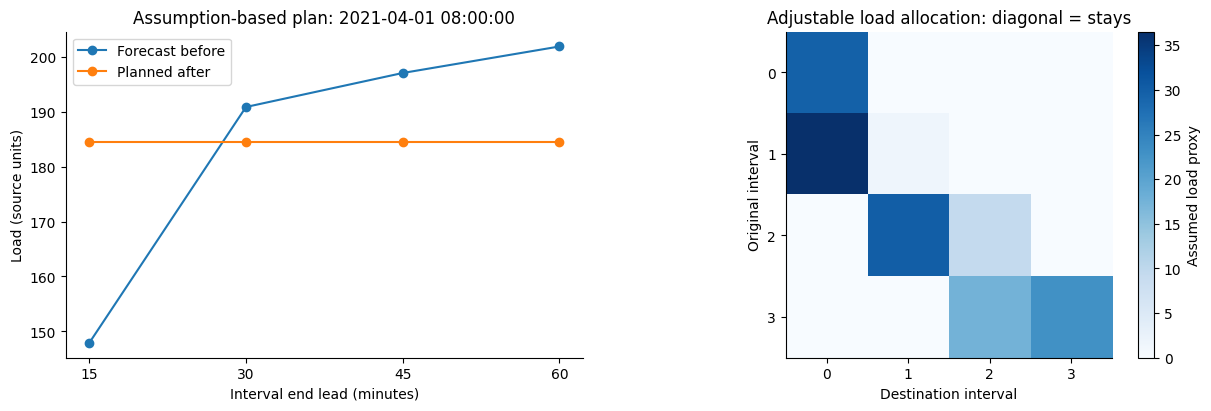

부하 보존·수용 한도·이동 범위 제약 검증 완료
실제 제품 생산량 보존은 검증하지 않았습니다.
조건부 재생은 실측 절감량이나 요금 절감액이 아닙니다.


In [24]:
replay_valid = opt_results.loc[opt_results["replay_feasible"]].copy()
replay_valid["peak_increased"] = (
    replay_valid["replay_after"] > replay_valid["actual_before"] + 1e-06
)
replay_summary = replay_valid.groupby("scenario", sort=False).agg(
    feasible_n=("timestamp", "size"),
    mean_actual_before=("actual_before", "mean"),
    mean_replay_after=("replay_after", "mean"),
    mean_replay_reduction_pct=("replay_reduction_pct", "mean"),
    peak_increase_rate=("peak_increased", "mean"),
)
replay_summary["excluded_n"] = opt_summary["n"] - replay_summary["feasible_n"]
print("같은 가용 표본끼리 비교한 조건부 재생 결과")
print("실측 절감 결과가 아닙니다.")
display(replay_summary.round(4))
save_table(replay_summary, OPT_OUT / "conditional_replay_summary.csv", index=True)
example_t = (
    opt_results.loc[opt_results["scenario"].eq("20pct_15min") & opt_results["eligible"]]
    .sort_values("pred_before", ascending=False)
    .iloc[0]["timestamp"]
)
example_row = opt_cases.loc[opt_cases["timestamp"].eq(example_t)].iloc[0]
p = example_row[[f"pred_{h}" for h in HORIZONS]].to_numpy(dtype=float)
example_plan = optimize_hour_profile(p, eta=0.2, max_shift=1, eligible=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].plot(HORIZONS, p, marker="o", label="Forecast before")
axes[0].plot(HORIZONS, example_plan["after"], marker="o", label="Planned after")
axes[0].set(
    title=f"Assumption-based plan: {example_t}",
    xlabel="Interval end lead (minutes)",
    ylabel="Load (source units)",
    xticks=HORIZONS,
)
axes[0].legend()
image = axes[1].imshow(example_plan["flow"], cmap="Blues")
axes[1].set(
    title="Adjustable load allocation: diagonal = stays",
    xlabel="Destination interval",
    ylabel="Original interval",
    xticks=range(4),
    yticks=range(4),
)
fig.colorbar(image, ax=axes[1], label="Assumed load proxy")
save_figure(fig, OPT_OUT / "03_plan_example.png", dpi=150)
print("부하 보존·수용 한도·이동 범위 제약 검증 완료")
print("실제 제품 생산량 보존은 검증하지 않았습니다.")
print("조건부 재생은 실측 절감량이나 요금 절감액이 아닙니다.")


## 6. 가상 조정의 역효과와 후보 규칙

### 25. 가상 부하 이동 결과의 행렬 구성

20%·30분 시나리오의 예측·실제·배정 프로파일을 같은 정시 원점 순서로 구성한다. 순이동량은 배정 후 예측−배정 전 예측이며, 가상 재생은 실제값+순이동량이다.

In [25]:
# 예측·실제·배정 후 부하를 같은 원점과 구간 순서로 맞춘다.
follow = (
    opt_results.loc[opt_results["scenario"].eq(SCENARIO)]
    .set_index("timestamp")
    .sort_index()
    .copy()
)
scenario_profiles = opt_profiles.loc[opt_profiles["scenario"].eq(SCENARIO)].copy()
forecasts = hour_predictions.loc[hour_predictions["model"].eq("HGB_w5")].set_index(
    "timestamp"
)
assert follow.index.is_unique
assert forecasts.index.is_unique


def profile_matrix(column):
    """해당 시나리오의 네 구간 값을 예측 원점 순서의 행렬로 변환한다."""
    return (
        scenario_profiles.pivot(index="timestamp", columns="horizon_min", values=column)
        .reindex(index=follow.index, columns=HORIZONS)
        .to_numpy(dtype=float)
    )


forecast_profiles = profile_matrix("prediction")
actual_profiles = profile_matrix("actual")
planned_profiles = profile_matrix("planned")
net_transfers = planned_profiles - forecast_profiles
replay_profiles = actual_profiles + net_transfers
assert np.isfinite(forecast_profiles).all()
assert np.isfinite(actual_profiles).all()
assert np.isfinite(planned_profiles).all()
assert np.allclose(net_transfers.sum(axis=1), 0, atol=EPS)
assert np.all(planned_profiles.max(axis=1) <= forecast_profiles.max(axis=1) + EPS)
assert np.allclose(follow["actual_before"], actual_profiles.max(axis=1))
valid_mask = follow["replay_feasible"].to_numpy(dtype=bool)
assert np.allclose(
    follow.loc[follow["replay_feasible"], "replay_after"],
    replay_profiles[valid_mask].max(axis=1),
)
follow["threshold"] = forecasts["threshold"].reindex(follow.index)
assert follow["threshold"].notna().all()
print("분석 시나리오:", SCENARIO)
print(f"전체 한 시간 창: {len(follow):,}개")
print(f"조건부 재생 가능 창: {valid_mask.sum():,}개")
print("※ 실제 작업을 옮긴 결과가 아니라 가상 조정 평가입니다.")


분석 시나리오: 20pct_30min
전체 한 시간 창: 3,672개
조건부 재생 가능 창: 3,622개
※ 실제 작업을 옮긴 결과가 아니라 가상 조정 평가입니다.


### 26. 최대값 변화와 분모별 집계

감소·유지·증가는 특정 수신 구간의 변화가 아니라 한 시간 전체 최대값의 변화이다. 사후 재생 가능 창 전체와 실제로 가상 배정이 바뀐 창을 별도 분모로 집계한다.

,denominator,outcome,n,total,rate_pct
0,All feasible windows,decreased,1436,3622,39.647
1,All feasible windows,unchanged,1446,3622,39.923
2,All feasible windows,increased,740,3622,20.431
3,Simulated moved windows,decreased,1436,2176,65.993
4,Simulated moved windows,unchanged,0,2176,0.000
5,Simulated moved windows,increased,740,2176,34.007


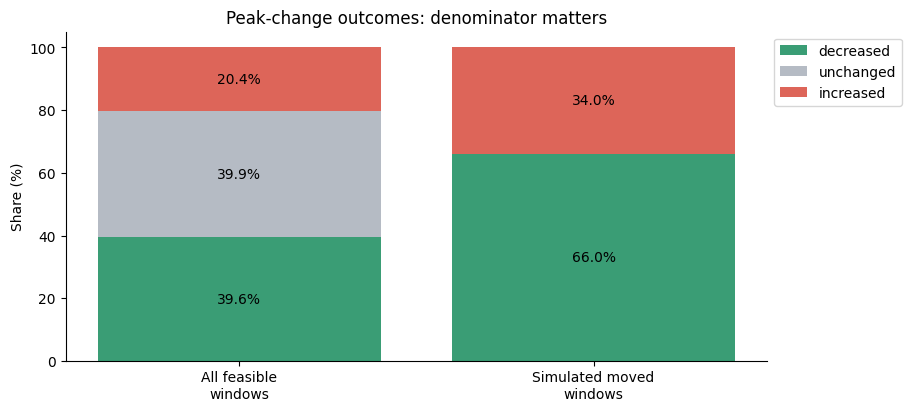

In [26]:
follow["action"] = np.max(np.abs(net_transfers), axis=1) > EPS
follow["peak_change"] = replay_profiles.max(axis=1) - actual_profiles.max(axis=1)
follow["outcome"] = np.select(
    [follow["peak_change"] > EPS, follow["peak_change"] < -EPS],
    ["increased", "decreased"],
    default="unchanged",
)
valid = follow.loc[follow["replay_feasible"]].copy()
active = valid.loc[valid["action"]].copy()
outcome_rows = []
for label, subset in [
    ("All feasible windows", valid),
    ("Simulated moved windows", active),
]:
    for outcome in ["decreased", "unchanged", "increased"]:
        count = int(subset["outcome"].eq(outcome).sum())
        outcome_rows.append(
            {
                "denominator": label,
                "outcome": outcome,
                "n": count,
                "total": len(subset),
                "rate_pct": 100 * count / len(subset),
            }
        )
outcome_summary = pd.DataFrame(outcome_rows)
display(outcome_summary.round(3))
save_table(outcome_summary, FOLLOW_OUT / "outcome_denominators.csv", index=False)
fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
bottom = np.zeros(2)
for outcome, color in [
    ("decreased", "#3a9d75"),
    ("unchanged", "#b5bbc4"),
    ("increased", "#dd6559"),
]:
    values = outcome_summary.loc[
        outcome_summary["outcome"].eq(outcome), "rate_pct"
    ].to_numpy()
    ax.bar(
        ["All feasible\nwindows", "Simulated moved\nwindows"],
        values,
        bottom=bottom,
        label=outcome,
        color=color,
    )
    for i, value in enumerate(values):
        if value > 3:
            ax.text(i, bottom[i] + value / 2, f"{value:.1f}%", ha="center", va="center")
    bottom += values
ax.set(
    title="Peak-change outcomes: denominator matters", ylabel="Share (%)", ylim=(0, 105)
)
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
save_figure(fig, FOLLOW_OUT / "01_outcome_denominators.png", dpi=160)


### 27. 피크 증가 사례의 예측 오류 분석

증가 사례와 감소 사례의 전체 오차, 예측·실제 최대 구간 불일치, 실제 최대 구간으로의 유입, 수신 구간 과소예측을 비교한다. 최대값 동률이 있으면 최대 구간 중 하나라도 겹칠 때 일치로 판정한다.

False: 피크 증가 없음 / True: 피크 증가


,increased,n,mean_profile_mae,peak_time_mismatch_pct,received_at_actual_peak_pct,mean_receiver_underprediction,mean_sender_overprediction
0,False,1436,7.889,40.181,0.000,1.997,3.043
1,True,740,8.324,83.108,75.405,6.691,6.161


,value,n,increased_n,mean_profile_mae,increase_rate_pct,condition
0,4,456,182,9.055,39.912,fold_month
1,5,418,124,7.646,29.665,fold_month
2,6,490,134,6.551,27.347,fold_month
3,7,436,163,9.091,37.385,fold_month
4,8,376,137,7.952,36.436,fold_month
5,0,304,101,8.499,33.224,weekday
6,1,455,142,7.412,31.209,weekday
7,2,421,138,8.263,32.779,weekday
8,3,426,157,8.080,36.854,weekday
9,4,446,156,8.220,34.978,weekday


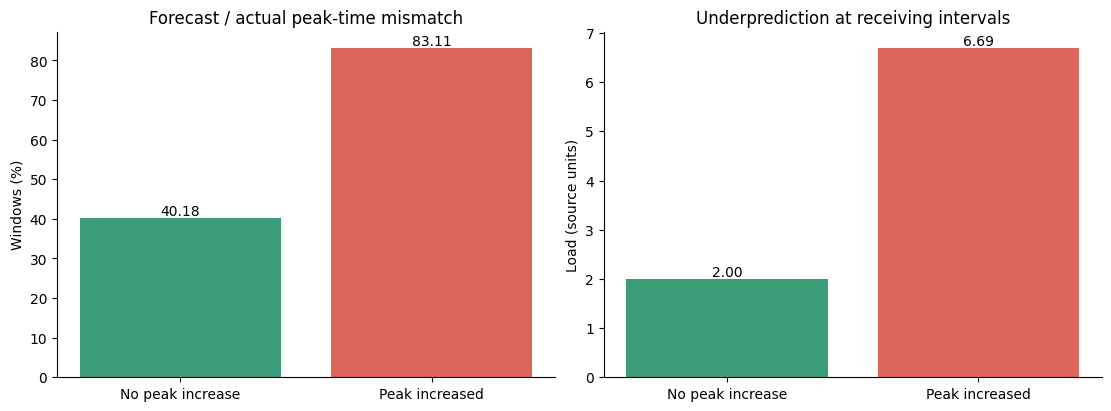

In [27]:
# 실제 피크 구간과 오류 변수는 사후 진단용이며 실행 조건에 사용하지 않는다.
receiving = np.maximum(net_transfers, 0)
sending = np.maximum(-net_transfers, 0)
follow["profile_mae"] = np.mean(np.abs(forecast_profiles - actual_profiles), axis=1)
pred_peak_positions = forecast_profiles >= forecast_profiles.max(axis=1)[:, None] - EPS
actual_peak_positions = actual_profiles >= actual_profiles.max(axis=1)[:, None] - EPS
follow["peak_time_mismatch"] = ~(pred_peak_positions & actual_peak_positions).any(
    axis=1
)
follow["received_at_actual_peak"] = ((net_transfers > EPS) & actual_peak_positions).any(
    axis=1
)
follow["receiver_underprediction"] = (
    np.maximum(actual_profiles - forecast_profiles, 0) * receiving
).sum(axis=1) / np.maximum(receiving.sum(axis=1), EPS)
follow["sender_overprediction"] = (
    np.maximum(forecast_profiles - actual_profiles, 0) * sending
).sum(axis=1) / np.maximum(sending.sum(axis=1), EPS)
follow["weekday"] = follow.index.dayofweek
follow["hour"] = follow.index.hour
valid = follow.loc[follow["replay_feasible"]].copy()
active = valid.loc[valid["action"]].copy()
active["increased"] = active["outcome"].eq("increased")
diagnostics = (
    active.groupby("increased")
    .agg(
        n=("action", "size"),
        mean_profile_mae=("profile_mae", "mean"),
        peak_time_mismatch_pct=("peak_time_mismatch", lambda s: 100 * s.mean()),
        received_at_actual_peak_pct=(
            "received_at_actual_peak",
            lambda s: 100 * s.mean(),
        ),
        mean_receiver_underprediction=("receiver_underprediction", "mean"),
        mean_sender_overprediction=("sender_overprediction", "mean"),
    )
    .reset_index()
)
print("False: 피크 증가 없음 / True: 피크 증가")
display(diagnostics.round(3))
save_table(diagnostics, FOLLOW_OUT / "error_diagnostics.csv", index=False)
condition_parts = []
for column in ["fold_month", "weekday", "hour"]:
    part = (
        active.groupby(column)
        .agg(
            n=("increased", "size"),
            increased_n=("increased", "sum"),
            mean_profile_mae=("profile_mae", "mean"),
        )
        .reset_index()
        .rename(columns={column: "value"})
    )
    part["increase_rate_pct"] = 100 * part["increased_n"] / part["n"]
    part["condition"] = column
    condition_parts.append(part)
condition_diagnostics = pd.concat(condition_parts, ignore_index=True)
display(condition_diagnostics.round(3))
save_table(condition_diagnostics, FOLLOW_OUT / "condition_diagnostics.csv", index=False)
save_table(follow, FOLLOW_OUT / "case_diagnostics.csv", index=True)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
labels = ["No peak increase", "Peak increased"]
plot_items = [
    (
        axes[0],
        "peak_time_mismatch_pct",
        "Forecast / actual peak-time mismatch",
        "Windows (%)",
    ),
    (
        axes[1],
        "mean_receiver_underprediction",
        "Underprediction at receiving intervals",
        "Load (source units)",
    ),
]
for ax, column, title, units in plot_items:
    values = diagnostics[column].to_numpy()
    ax.bar(labels, values, color=["#3a9d75", "#dd6559"])
    ax.set(title=title, ylabel=units)
    for i, value in enumerate(values):
        ax.text(i, value, f"{value:.2f}", ha="center", va="bottom")
save_figure(fig, FOLLOW_OUT / "02_error_diagnostics.png", dpi=160)


### 28. 예측 정보로 결정하는 조정 후보 규칙

예측 경보 및 예측 감소율 3% 이상 여부로 조정 후보를 비교한다. 3%는 설명용 후보값이다. 사후 재생 가능 창의 동일한 집합에서 비교하므로 현장 안전 보장이나 독립 검증 성능으로 해석하지 않는다.

,policy,common_feasible_n,action_n,increased_n,increase_rate_all_pct,increase_rate_actions_pct,mean_reduction_all_pct,actual_high_windows_before,replay_high_windows_after,newly_high_windows,resolved_high_windows,selected_infeasible_action_n
0,No adjustment,3622,0,0,0.000,NaN,0.000,458,458,0,0,0
1,All original plans,3622,2176,740,20.431,34.007,1.024,458,389,23,92,50
2,Alarm 100%,3622,315,92,2.540,29.206,0.106,458,428,5,35,3
3,Alarm 95%,3622,552,180,4.970,32.609,0.209,458,402,15,71,6
4,Alarm 95% + predicted gain >=3%,3622,247,42,1.160,17.004,0.206,458,409,6,55,6


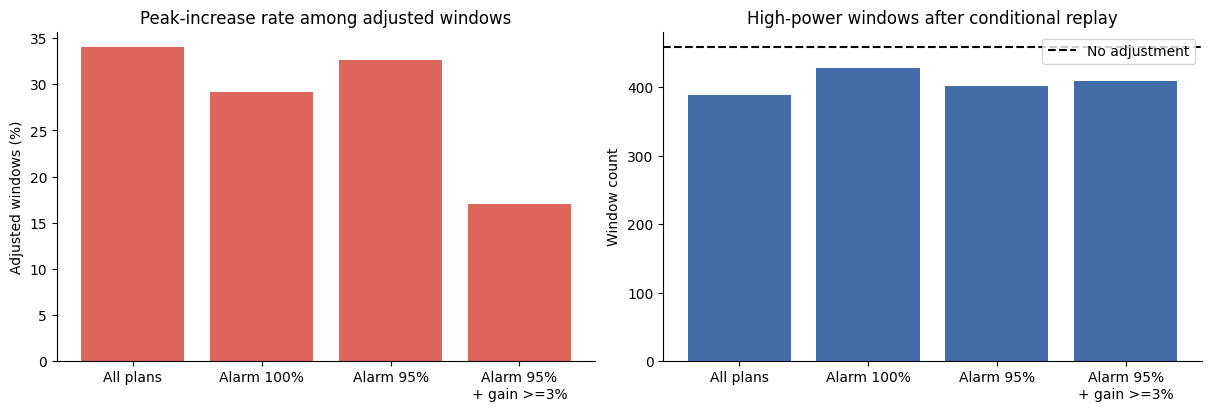

In [28]:
# 규칙 자체는 예측 정보만 사용하며 재생 가능 표본 선택은 사후에 수행한다.
gates = {
    "No adjustment": pd.Series(False, index=follow.index),
    "All original plans": pd.Series(True, index=follow.index),
    "Alarm 100%": follow["pred_before"] >= follow["threshold"],
    "Alarm 95%": follow["pred_before"] >= 0.95 * follow["threshold"],
    "Alarm 95% + predicted gain >=3%": (
        follow["pred_before"] >= 0.95 * follow["threshold"]
    )
    & (follow["pred_reduction_pct"] >= 3),
}
policy_rows = []
for name, gate in gates.items():
    g = gate.reindex(valid.index)
    after = np.where(g, valid["replay_after"], valid["actual_before"])
    action = g & valid["action"]
    increased = after > valid["actual_before"].to_numpy() + EPS
    before_peak = valid["actual_before"] >= valid["threshold"]
    after_peak = after >= valid["threshold"].to_numpy()
    action_n = int(action.sum())
    increased_n = int(increased.sum())
    policy_rows.append(
        {
            "policy": name,
            "common_feasible_n": len(valid),
            "action_n": action_n,
            "increased_n": increased_n,
            "increase_rate_all_pct": 100 * increased.mean(),
            "increase_rate_actions_pct": (
                100 * increased_n / action_n if action_n else np.nan
            ),
            "mean_reduction_all_pct": np.mean(
                100
                * (valid["actual_before"].to_numpy() - after)
                / np.maximum(valid["actual_before"].to_numpy(), EPS)
            ),
            "actual_high_windows_before": int(before_peak.sum()),
            "replay_high_windows_after": int(after_peak.sum()),
            "newly_high_windows": int((~before_peak.to_numpy() & after_peak).sum()),
            "resolved_high_windows": int((before_peak.to_numpy() & ~after_peak).sum()),
            "selected_infeasible_action_n": int(
                (gate & follow["action"] & ~follow["replay_feasible"]).sum()
            ),
        }
    )
policy_summary = pd.DataFrame(policy_rows)
display(policy_summary.round(3))
save_table(policy_summary, FOLLOW_OUT / "policy_comparison.csv", index=False)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
z = policy_summary.iloc[1:]
short_labels = ["All plans", "Alarm 100%", "Alarm 95%", "Alarm 95%\n+ gain >=3%"]
axes[0].bar(short_labels, z["increase_rate_actions_pct"], color="#dd6559")
axes[0].set(
    title="Peak-increase rate among adjusted windows", ylabel="Adjusted windows (%)"
)
axes[1].bar(short_labels, z["replay_high_windows_after"], color="#426da9")
axes[1].axhline(
    policy_summary.iloc[0]["actual_high_windows_before"],
    color="black",
    linestyle="--",
    label="No adjustment",
)
axes[1].set(title="High-power windows after conditional replay", ylabel="Window count")
axes[1].legend()
save_figure(fig, FOLLOW_OUT / "03_policy_comparison.png", dpi=160)


### 29. 피크 증가 사례의 네 구간 비교

실제 고전력과 경보가 함께 있었던 증가 사례 중 최대 증가량 사례를 설명한다. 사후 선정 사례이며 전체 효과를 대표하지 않는다.

사후 선정한 설명 사례: 2021-04-09 08:00:00


,interval_start,prediction,planned_prediction,actual,net_transfer,conditional_replay
0,2021-04-09 08:00:00,164.379,164.039,160.0,-0.340,159.660
1,2021-04-09 08:15:00,183.329,164.039,180.0,-19.290,160.710
2,2021-04-09 08:30:00,174.230,164.039,182.0,-10.191,171.809
3,2021-04-09 08:45:00,134.218,164.039,184.0,29.821,213.821


예측 최대값: 183.33 → 164.04
실제 관측 / 가상 재생 최대값: 184.00 → 213.82


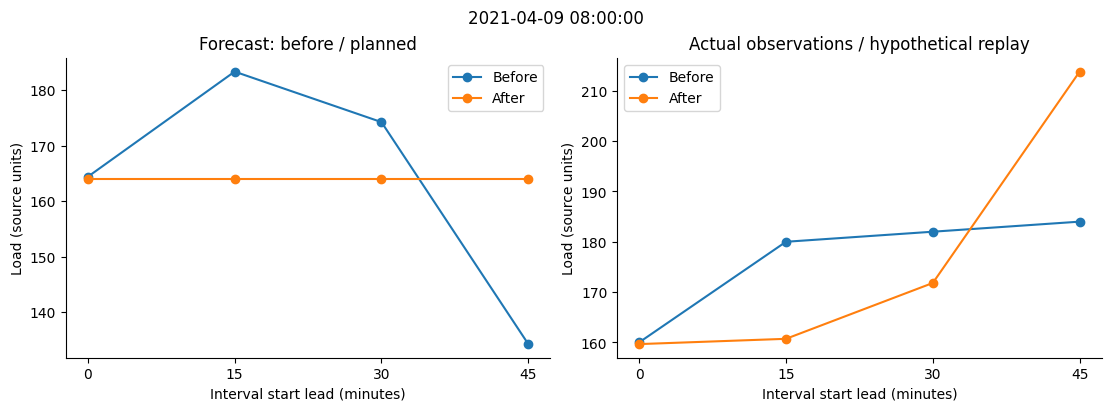

분석 완료: /content/output/kai_followup
※ 기존 검증 기간을 재사용한 탐색 분석입니다.
※ 실제 현장 절감 실험이나 전기요금 절감 결과가 아닙니다.


In [29]:
example_pool = active.loc[
    active["increased"]
    & (active["actual_before"] >= active["threshold"])
    & (active["pred_before"] >= 0.95 * active["threshold"])
]
if len(example_pool):
    example_time = example_pool["peak_change"].idxmax()
else:
    increased_cases = active.loc[active["increased"]]
    if increased_cases.empty:
        raise RuntimeError("피크 증가 사례가 없습니다.")
    example_time = increased_cases["peak_change"].idxmax()
idx = follow.index.get_loc(example_time)
example = pd.DataFrame(
    {
        "interval_start": [
            example_time + pd.Timedelta(minutes=m) for m in [0, 15, 30, 45]
        ],
        "prediction": forecast_profiles[idx],
        "planned_prediction": planned_profiles[idx],
        "actual": actual_profiles[idx],
        "net_transfer": net_transfers[idx],
        "conditional_replay": replay_profiles[idx],
    }
)
print("사후 선정한 설명 사례:", example_time)
display(example.round(3))
print(
    f"예측 최대값: {forecast_profiles[idx].max():.2f} → {planned_profiles[idx].max():.2f}"
)
print(
    f"실제 관측 / 가상 재생 최대값: {actual_profiles[idx].max():.2f} → {replay_profiles[idx].max():.2f}"
)
save_table(example, FOLLOW_OUT / "example_profile.csv", index=False)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
plot_items = [
    (
        axes[0],
        forecast_profiles[idx],
        planned_profiles[idx],
        "Forecast: before / planned",
    ),
    (
        axes[1],
        actual_profiles[idx],
        replay_profiles[idx],
        "Actual observations / hypothetical replay",
    ),
]
for ax, before, after, title in plot_items:
    ax.plot([0, 15, 30, 45], before, marker="o", label="Before")
    ax.plot([0, 15, 30, 45], after, marker="o", label="After")
    ax.set(
        title=title,
        xlabel="Interval start lead (minutes)",
        ylabel="Load (source units)",
        xticks=[0, 15, 30, 45],
    )
    ax.legend()
fig.suptitle(str(example_time))
save_figure(fig, FOLLOW_OUT / "04_real_failure_example.png", dpi=160)
print("분석 완료:", FOLLOW_OUT.resolve())
print("※ 기존 검증 기간을 재사용한 탐색 분석입니다.")
print("※ 실제 현장 절감 실험이나 전기요금 절감 결과가 아닙니다.")


## 7. 결과 점검과 사전 경고 가능 시간

### 30. 예측 결과의 일관성 점검

네 모델의 평가 원점·실제값·기준이 같은지, 중복·결측·음수 예측이 없는지, 네 구간의 최대값과 미래 실제 구간 연결이 맞는지 확인한다. 예측 결과의 일관성 점검은 학습 과정의 모든 정보 누출을 검증하는 것은 아니다.

In [30]:
final_predictions = hour_predictions.copy()
final_predictions["timestamp"] = pd.to_datetime(final_predictions["timestamp"])
final_predictions["fold_month"] = final_predictions["fold_month"].astype(int)
final_predictions = final_predictions.loc[
    final_predictions["fold_month"].between(4, 8)
    & final_predictions["model"].isin(HOUR_MODELS)
].copy()
needed = ["threshold", "actual_max", "predicted_max"] + [
    f"{kind}_{h}" for kind in ["actual", "pred"] for h in HORIZONS
]
assert not final_predictions.empty, "4~8월 예측 결과가 없음"
assert set(HOUR_MODELS).issubset(
    set(final_predictions["model"])
), "기존 네 모델의 예측 결과가 필요함"
assert not final_predictions["timestamp"].isna().any(), "예측 원점에 결측이 있음"
assert not final_predictions.duplicated(
    ["timestamp", "model"]
).any(), "모델별 예측 원점이 중복됨"
assert np.isfinite(
    final_predictions[needed].to_numpy(dtype=float)
).all(), "수치 결측 또는 무한대가 있음"
assert (
    (final_predictions[[f"pred_{h}" for h in HORIZONS]] >= 0).all().all()
), "음수 예측값이 있음"
assert np.allclose(
    final_predictions["actual_max"],
    final_predictions[[f"actual_{h}" for h in HORIZONS]].max(axis=1),
), "실제 최대값 계산이 다름"
assert np.allclose(
    final_predictions["predicted_max"],
    final_predictions[[f"pred_{h}" for h in HORIZONS]].max(axis=1),
), "예측 최대값 계산이 다름"
final_ref = (
    final_predictions.loc[final_predictions["model"].eq("HGB_w1")]
    .sort_values("timestamp")
    .set_index("timestamp")
)
for model in HOUR_MODELS:
    check = (
        final_predictions.loc[final_predictions["model"].eq(model)]
        .sort_values("timestamp")
        .set_index("timestamp")
    )
    assert check.index.equals(final_ref.index), f"{model}: 비교 시점이 다름"
    comparison_cols = ["threshold"] + [f"actual_{h}" for h in HORIZONS]
    assert np.allclose(
        check[comparison_cols], final_ref[comparison_cols]
    ), f"{model}: 기준 또는 실제값이 다름"
    assert (
        check.groupby("fold_month")["threshold"].nunique().eq(1).all()
    ), "월 안에서 고전력 기준이 달라짐"
    for _, month_data in check.groupby("fold_month"):
        assert (
            month_data.index.to_series()
            .diff()
            .dropna()
            .eq(pd.Timedelta(minutes=15))
            .all()
        ), "15분 원점 예측 결과가 필요함"
    for h in HORIZONS[1:]:
        target_times = check.index + pd.Timedelta(minutes=h - 15)
        available = target_times.isin(check.index)
        assert np.allclose(
            check.loc[available, f"actual_{h}"].to_numpy(),
            check["actual_15"].reindex(target_times[available]).to_numpy(),
        ), f"{model}: 미래 실제 구간 연결이 다름"
print("점검 통과: 동일 평가 시점·실제값·기준, 중복·결측, 최대값, 미래 구간 연결 확인")
print("모델별 정시 원점 수:")
display(
    final_predictions.loc[final_predictions["timestamp"].dt.minute.eq(0)]
    .groupby("model")
    .size()
    .rename("n")
    .reset_index()
)


점검 통과: 동일 평가 시점·실제값·기준, 중복·결측, 최대값, 미래 구간 연결 확인
모델별 정시 원점 수:


,model,n
0,HGB_w1,3672
1,HGB_w5,3672
2,Persistence,3672
3,WeeklyNaive,3672


### 31. 최종 정확도·경보 성능 요약

이미 계산한 구간별 오차·한 시간 최대값 오차·월별 경보 건수를 재사용한다. 오차는 월별 평균, 혼동행렬은 월별 합산으로 집계한다. 같은 예측값으로 지표를 중복 계산하지 않는다.

In [31]:
# 기존 오차 지표와 월별 경보 건수를 재사용한다.
final_horizon_monthly = hour_horizons.rename(columns={"fold_month": "month"})[
    ["model", "month", "horizon_min", "MAE", "peak_MAE", "peak_underprediction"]
].copy()
hourly_errors = hour_windows.loc[hour_windows["cadence"].eq("hourly_origins")][
    ["model", "fold_month", "MAE", "peak_MAE", "peak_underprediction"]
]
monthly_alarms = hour_alarm_monthly.loc[
    hour_alarm_monthly["cadence"].eq("hourly_origins")
    & hour_alarm_monthly["ratio"].isin([1.0, 0.95])
]
final_hour_monthly = (
    monthly_alarms.merge(
        hourly_errors, on=["model", "fold_month"], validate="many_to_one"
    )
    .rename(
        columns={
            "fold_month": "month",
            "peak_n": "actual_high",
            "MAE": "max_MAE",
            "tp": "TP",
            "fn": "FN",
            "fp": "FP",
            "tn": "TN",
        }
    )[
        [
            "model",
            "month",
            "ratio",
            "n",
            "actual_high",
            "max_MAE",
            "peak_MAE",
            "peak_underprediction",
            "TP",
            "FN",
            "FP",
            "TN",
        ]
    ]
    .copy()
)
final_hour_summary = (
    final_hour_monthly.groupby(["model", "ratio"])
    .agg(
        n=("n", "sum"),
        actual_high=("actual_high", "sum"),
        max_MAE=("max_MAE", "mean"),
        peak_MAE=("peak_MAE", "mean"),
        peak_underprediction=("peak_underprediction", "mean"),
        TP=("TP", "sum"),
        FN=("FN", "sum"),
        FP=("FP", "sum"),
        TN=("TN", "sum"),
    )
    .reset_index()
)
final_hour_summary["recall_pct"] = (
    100
    * final_hour_summary["TP"]
    / final_hour_summary["actual_high"].replace(0, np.nan)
)
final_hour_summary["precision_pct"] = (
    100
    * final_hour_summary["TP"]
    / (final_hour_summary["TP"] + final_hour_summary["FP"]).replace(0, np.nan)
)
final_horizon_summary = (
    final_horizon_monthly.groupby(["model", "horizon_min"])[
        ["MAE", "peak_MAE", "peak_underprediction"]
    ]
    .mean()
    .reset_index()
)
print("정시 원점의 한 시간 최대값 및 경보 비교: 오차는 월별 평균, 경보 건수는 합산")
display(final_hour_summary.round(4))
print("예측 구간별 비교: 15분마다 발행한 예측 사용, 월별 오차 평균")
display(final_horizon_summary.round(4))


정시 원점의 한 시간 최대값 및 경보 비교: 오차는 월별 평균, 경보 건수는 합산


,model,ratio,n,actual_high,max_MAE,peak_MAE,peak_underprediction,TP,FN,FP,TN,recall_pct,precision_pct
0,HGB_w1,0.95,3672,460,7.4135,12.7141,12.2110,364,96,108,3104,79.1304,77.1186
1,HGB_w1,1.00,3672,460,7.4135,12.7141,12.2110,228,232,12,3200,49.5652,95.0000
2,HGB_w5,0.95,3672,460,7.5943,9.4634,8.5947,409,51,200,3012,88.9130,67.1593
3,HGB_w5,1.00,3672,460,7.5943,9.4634,8.5947,307,153,49,3163,66.7391,86.2360
4,Persistence,0.95,3672,460,11.9553,27.5383,26.4293,281,179,208,3004,61.0870,57.4642
5,Persistence,1.00,3672,460,11.9553,27.5383,26.4293,206,254,96,3116,44.7826,68.2119
6,WeeklyNaive,0.95,3672,460,23.4111,35.0389,32.9507,310,150,352,2860,67.3913,46.8278
7,WeeklyNaive,1.00,3672,460,23.4111,35.0389,32.9507,237,223,218,2994,51.5217,52.0879


예측 구간별 비교: 15분마다 발행한 예측 사용, 월별 오차 평균


,model,horizon_min,MAE,peak_MAE,peak_underprediction
0,HGB_w1,15,5.2655,9.4556,8.7776
1,HGB_w1,30,6.7797,12.2965,11.8673
2,HGB_w1,45,7.4237,13.2896,12.6999
3,HGB_w1,60,8.0875,14.9261,14.2604
4,HGB_w5,15,5.3634,7.4604,6.3571
5,HGB_w5,30,7.1396,10.2296,9.2158
6,HGB_w5,45,7.9243,10.3787,9.3585
7,HGB_w5,60,8.2505,11.5159,10.3423
8,Persistence,15,8.1831,11.7327,10.0912
9,Persistence,30,12.5095,23.5419,21.9612


### 32. 고전력 구간 시작 전 경고 가능 시간

직전 실제 구간은 기준 미만이고 현재 실제 구간은 기준 이상인 시점을 고전력 시작으로 정의한다. 시작 45·30·15분 전과 시작 시점에서 해당 시작 구간을 예측한 값을 확인한다. 45분 전에는 pred_60을 확인한다. 0은 시작 시점에서만 탐지, −1은 확인한 네 시점에서 해당 시작 구간을 탐지하지 못한 경우이다. 시간은 15분 구간 시작에 대한 여유 시간이며 정확한 순간 피크에 대한 시간은 아니다.

In [32]:
# 같은 시작 구간에 대한 네 발행 시점의 예측을 비교한다.
final_high = final_ref["actual_15"] >= final_ref["threshold"]
previous_times = final_ref.index - pd.Timedelta(minutes=15)
previous_high = (
    final_high.reindex(previous_times)
    .astype("boolean")
    .fillna(True)
    .to_numpy(dtype=bool)
)
previous_month = final_ref["fold_month"].reindex(previous_times).to_numpy()
known_previous = previous_times.isin(final_ref.index) & (
    previous_month == final_ref["fold_month"].to_numpy()
)
final_onsets = final_ref.index[final_high.to_numpy() & known_previous & ~previous_high]
final_eligible_onsets = []
for onset in final_onsets:
    issues = [onset - pd.Timedelta(minutes=lead) for lead in LEAD_MINUTES]
    if all((t in final_ref.index for t in issues)) and all(
        (
            final_ref.loc[t, "fold_month"] == final_ref.loc[onset, "fold_month"]
            for t in issues
        )
    ):
        final_eligible_onsets.append(onset)
if not final_eligible_onsets:
    raise ValueError("네 발행 시점을 모두 비교할 수 있는 고전력 시작 사례가 없음")
final_event_rows = []
for model in ["HGB_w1", "HGB_w5"]:
    forecasts = final_predictions.loc[final_predictions["model"].eq(model)].set_index(
        "timestamp"
    )
    for ratio in [1.0, 0.95]:
        for onset in final_eligible_onsets:
            earliest = -1
            for lead in LEAD_MINUTES:
                issue = onset - pd.Timedelta(minutes=lead)
                # 시작 45분 전 발행한 pred_60이 해당 시작 구간을 예측한다.
                h = lead + 15
                if (
                    forecasts.loc[issue, f"pred_{h}"]
                    >= ratio * final_ref.loc[onset, "threshold"]
                ):
                    earliest = lead
                    break
            final_event_rows.append(
                {
                    "model": model,
                    "ratio": ratio,
                    "onset": onset,
                    "month": int(final_ref.loc[onset, "fold_month"]),
                    "lead_start_min": earliest,
                }
            )
final_events = pd.DataFrame(final_event_rows)
final_events["before_start"] = final_events["lead_start_min"].ge(15)
final_event_summary = (
    final_events.groupby(["model", "ratio"])
    .agg(
        n=("onset", "size"),
        before_start_n=("before_start", "sum"),
        before_start_pct=("before_start", lambda x: 100 * x.mean()),
    )
    .reset_index()
)
for lead in LEAD_MINUTES + [-1]:
    counts = (
        final_events.assign(hit=final_events["lead_start_min"].eq(lead))
        .groupby(["model", "ratio"])["hit"]
        .sum()
    )
    final_event_summary[f"lead_{lead}_n"] = [
        int(counts.loc[m, r])
        for m, r in zip(final_event_summary["model"], final_event_summary["ratio"])
    ]
final_event_monthly = (
    final_events.groupby(["model", "ratio", "month"])
    .agg(
        n=("onset", "size"),
        before_start_n=("before_start", "sum"),
        before_start_pct=("before_start", lambda x: 100 * x.mean()),
    )
    .reset_index()
)
print(
    f"확인된 고전력 시작 {len(final_onsets)}개 / 네 발행 시점 공통 비교 {len(final_eligible_onsets)}개"
)
print("lead_0: 시작 시점에서만 탐지, lead_-1: 검사한 네 시점에서 미탐지")
display(final_event_summary.round(4))
display(final_event_monthly.round(3))


확인된 고전력 시작 380개 / 네 발행 시점 공통 비교 380개
lead_0: 시작 시점에서만 탐지, lead_-1: 검사한 네 시점에서 미탐지


,model,ratio,n,before_start_n,before_start_pct,lead_45_n,lead_30_n,lead_15_n,lead_0_n,lead_-1_n
0,HGB_w1,0.95,380,286,75.2632,247,25,14,33,61
1,HGB_w1,1.00,380,149,39.2105,106,26,17,7,224
2,HGB_w5,0.95,380,334,87.8947,300,17,17,17,29
3,HGB_w5,1.00,380,234,61.5789,201,19,14,17,129


,model,ratio,month,n,before_start_n,before_start_pct
0,HGB_w1,0.95,4,31,11,35.484
1,HGB_w1,0.95,5,30,21,70.000
2,HGB_w1,0.95,6,100,85,85.000
3,HGB_w1,0.95,7,131,100,76.336
4,HGB_w1,0.95,8,88,69,78.409
5,HGB_w1,1.00,4,31,4,12.903
6,HGB_w1,1.00,5,30,9,30.000
7,HGB_w1,1.00,6,100,48,48.000
8,HGB_w1,1.00,7,131,61,46.565
9,HGB_w1,1.00,8,88,27,30.682


### 33. 사전 경고 가능 시간의 시각화와 결과 저장

경고 가능 시점의 구성과 월별 사전 경고 가능 비율을 시각화한다. 380개 시작 사례의 비율은 정시 고전력 한 시간 창 460개의 탐지율과 집계 단위가 다르다. 실제 경보 전달이나 현장 조치 효과를 평가한 결과는 아니다.

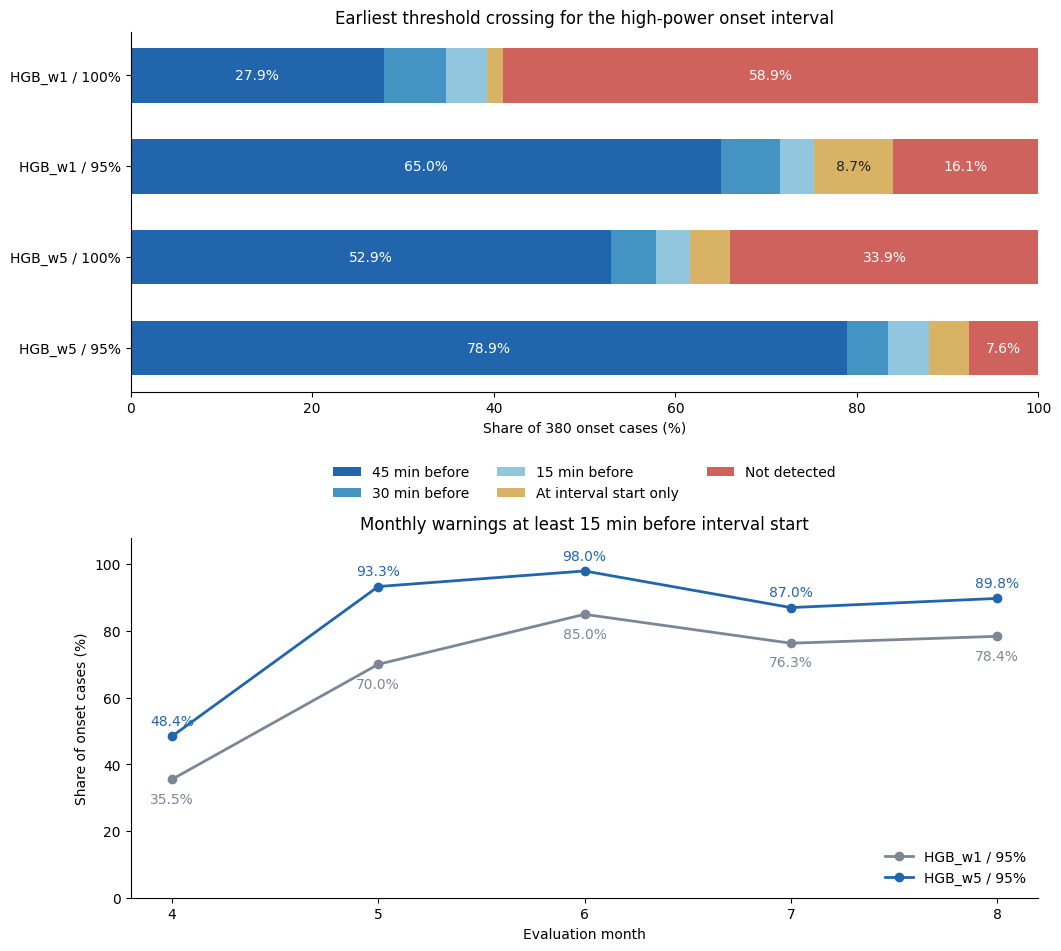

저장 위치: /content/output/kai_closeout


In [33]:
order = [("HGB_w1", 1.0), ("HGB_w1", 0.95), ("HGB_w5", 1.0), ("HGB_w5", 0.95)]
labels = [f"{m} / {r:.0%}" for m, r in order]
plot_rows = [
    final_event_summary.loc[
        final_event_summary["model"].eq(m) & np.isclose(final_event_summary["ratio"], r)
    ].iloc[0]
    for m, r in order
]
fig, axes = plt.subplots(2, 1, figsize=(10.5, 9.4), constrained_layout=True)
left = np.zeros(len(order))
lead_styles = [
    (45, "45 min before", "#2166ac"),
    (30, "30 min before", "#4393c3"),
    (15, "15 min before", "#92c5de"),
    (0, "At interval start only", "#d8b365"),
    (-1, "Not detected", "#cf625c"),
]
for lead, label, color in lead_styles:
    values = np.array([row[f"lead_{lead}_n"] / row["n"] * 100 for row in plot_rows])
    axes[0].barh(labels, values, left=left, color=color, label=label, height=0.6)
    for i, value in enumerate(values):
        if value >= 7:
            axes[0].text(
                left[i] + value / 2,
                i,
                f"{value:.1f}%",
                ha="center",
                va="center",
                color="white" if lead in [45, -1] else "#222",
            )
    left += values
axes[0].invert_yaxis()
axes[0].set_xlim(0, 100)
axes[0].set_title("Earliest threshold crossing for the high-power onset interval")
axes[0].set_xlabel(f"Share of {len(final_eligible_onsets)} onset cases (%)")
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.17), ncol=3, frameon=False)
for model, color in [("HGB_w1", "#7c8796"), ("HGB_w5", "#2166ac")]:
    group = final_event_monthly.loc[
        final_event_monthly["model"].eq(model)
        & np.isclose(final_event_monthly["ratio"], 0.95)
    ]
    axes[1].plot(
        group["month"],
        group["before_start_pct"],
        marker="o",
        linewidth=2,
        label=f"{model} / 95%",
        color=color,
    )
    for _, row in group.iterrows():
        axes[1].annotate(
            f"{row['before_start_pct']:.1f}%",
            (row["month"], row["before_start_pct"]),
            xytext=(0, 8 if model == "HGB_w5" else -17),
            textcoords="offset points",
            ha="center",
            color=color,
        )
axes[1].set_xticks(VALIDATION_MONTHS)
axes[1].set_ylim(0, 108)
axes[1].set_title("Monthly warnings at least 15 min before interval start")
axes[1].set_xlabel("Evaluation month")
axes[1].set_ylabel("Share of onset cases (%)")
axes[1].legend(loc="lower right", frameon=False)
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
save_figure(fig, CLOSEOUT_OUT / "alarm_lead_analysis.png", dpi=160, bbox_inches="tight")
tables_to_save = {
    "hour_max_monthly": final_hour_monthly,
    "hour_max_summary": final_hour_summary,
    "horizon_monthly": final_horizon_monthly,
    "horizon_summary": final_horizon_summary,
    "episode_leads": final_events,
    "episode_summary": final_event_summary,
    "episode_monthly": final_event_monthly,
}
for name, table in tables_to_save.items():
    save_table(table, CLOSEOUT_OUT / f"{name}.csv", index=False)
print("저장 위치:", CLOSEOUT_OUT.resolve())


## 결과 파일과 제출 시 해석

| 폴더 | 주요 결과 |
|---|---|
| `kai_models` | 기본 모델·피처 비교, 학습 창 비교, 9월 평가, 선택 모델 파일 |
| `kai_peak` | 가중치 비교, 15분 경보 기준 비교, 조건별 오류 |
| `kai_hour` | 네 구간 예측값, 구간별 정확도, 한 시간 경보·오류 조건 |
| `kai_optimization` | 고전력 발생 조건, 가상 부하 배정과 조건부 재생 |
| `kai_followup` | 최대값 증가·감소의 분모별 집계, 역효과 진단, 후보 규칙 비교 |
| `kai_closeout` | 최종 오차·경보 표, 사전 경고 가능 시간, 월별 성능 그래프 |

보고서에는 모델별 예측 정확도와 고전력 오차를 구분하고, 사전 경고 가능 비율과 오경보 부담을 함께 제시한다. 가상 부하 이동 결과는 일정 조정 검토를 위한 탐색적 근거로 설명한다. 실제 생산 일정·설비별 전력·작업 제약을 확보한 후에 현장 조정 효과를 별도로 검증하여야 한다.
